# VCI Bayes

## 1. Environment Setup

Import dependencies, configure plotting defaults, and align pyAgrum's visual output.

In [12]:
# Core Python utilities
import base64
import io
import os
import random
from itertools import product
from pathlib import Path

# Numerical and data processing
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Visualisation helpers
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from ipywidgets import interact, fixed

# Bayesian network tooling (pyAgrum ecosystem)
import pyagrum as gum
import pyagrum.lib.explain as explain
import pyagrum.lib.explain as expl
import pyagrum.lib.notebook as gnb
import pyagrum.lib.utils as gutils
import pyagrum.lib.bn2graph as gumb2g
import pyagrum.lib.bn_vs_bn as bnvsbn
import pyagrum.lib.bn_vs_bn as gcm
import pyagrum.lib.image as gumimage
from pyagrum import BNLearner
from pyagrum.lib.bn2roc import showROC
from pyagrum.lib.discreteTypeProcessor import DiscreteTypeProcessor
import pyagrum.skbn as skbn
from pyagrum.skbn import BNClassifier

# Scikit-learn helpers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings

# Matplotlib defaults for manuscript-ready figures
warnings.filterwarnings('ignore', category=UserWarning)

mpl.rcParams['font.family'] = 'Helvetica Neue'
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.weight'] = 'regular'


# ── Shared helpers from core/ ────────────────────────────────────────────
# These replace the local copies previously defined in cells 23, 30, 33, 70,
# 85 and 93 of this notebook. Behaviour is unchanged — see PORT_DIFF.md for
# the line-by-line comparison.
import sys as _sys
from pathlib import Path as _Path

_root = _Path.cwd().resolve()
while _root != _root.parent and not (_root / "core").is_dir():
    _root = _root.parent
if not (_root / "core").is_dir():
    raise RuntimeError(f"Could not locate `core/` above {_Path.cwd().resolve()}")
if str(_root) not in _sys.path:
    _sys.path.insert(0, str(_root))

from core.bn_utils import (
    build_bn,
    configure_guided_structure,
    bootstrap_edge_frequencies,
    bootstrap_scenario_risks,
    bootstrap_knob_sweep,
    descendants as _descendants,
)
from core.discretisation import (
    state_for_value as _state_for_value,
    format_bin_label as format_label,
)
from core.plotting import plot_knob_sweep
from core.spec import load_spec, check_against_dataframe


In [13]:
# Utility: format dictionaries for side-by-side HTML display in the notebook
def dict2html(di1, di2=None):
  res = "<br/>".join([f"<b>{k:15}</b>:{v}" for k, v in di1.items()])
  if di2 is not None:
    res += "<br/><br/>"
    res += "<br/>".join([f"<b>{k:15}</b>:{v}" for k, v in di2.items()])
  return res


In [14]:
# Ensure pyAgrum renders graphs with consistent layouts across reruns
gum.config["notebook", "graph_layout"] = "dot"
gum.config["notebook", "graph_rankdir"] = "TB"


## 2. Data Loading and Preparation

Set `PROJECT_ROOT` so that `PROJECT_ROOT / data` holds the parquet exports required for the analysis, or run `projects/HBC/preprocess_data.py` after configuring `config/data_paths.yml` to recreate them.

This notebook expects three inputs:
- `df.parquet`: raw cohort data without imputation (used for comparison plots).
- `df_imp.parquet`: fully imputed dataset feeding the Bayesian network learner.
- `bn_vars.parquet`: metadata table with at least `LAYER` and `VARIABLE NAME` columns describing the expert-assigned layer of each variable.

Update the configuration cell below if your repository layout differs.

In [ ]:
import os
import yaml
from pathlib import Path

# Load paths from config.yml (same file used by 00_preprocess.ipynb)
_config_candidates = [
    Path(__file__).parent / 'config.yml' if '__file__' in dir() else None,
    Path('config.yml'),
    Path('projects/HBC/config.yml'),
]
_config_path = next((p for p in _config_candidates if p is not None and p.exists()), None)

if _config_path is None:
    # Fallback: derive from this notebook's location via importlib
    import importlib.util
    _nb_dir = Path(importlib.util.find_spec('IPython').origin).parent  # any importable package
    raise FileNotFoundError(
        'config.yml not found. Place it next to the notebook or at projects/HBC/config.yml.'
    )

with open(_config_path) as _f:
    _cfg = yaml.safe_load(_f) or {}

PROJECT_ROOT = Path(_cfg['project_root']).expanduser().resolve()
DATA_DIR = Path(_cfg.get('output_dir', _cfg['project_root'])).expanduser().resolve()

# Verify DATA_DIR exists; fall back to project_root / 'data' if needed
if not DATA_DIR.exists():
    _fallback = PROJECT_ROOT / 'data'
    if _fallback.exists():
        DATA_DIR = _fallback
    else:
        raise FileNotFoundError(
            f'DATA_DIR={DATA_DIR} does not exist and no fallback found.'
        )

# Output directory for publication-ready PDF figures (editable in Illustrator).
OUTPUT_GRAPHS_DIR = PROJECT_ROOT / 'outputs' / 'graphs'
OUTPUT_GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

# ── Analysis specification ───────────────────────────────────────────────
# Every analysis CHOICE below -- layers and their order, network variants,
# discretisation, seed, bootstrap counts, scenario profiles, knob sweep --
# is read from spec.yml rather than hardcoded here. See SPEC_PLAN.md for
# the cell-by-cell provenance.
SPEC = load_spec(_config_path.parent / 'spec.yml')
print(f"Loaded spec '{SPEC.name}': {len(SPEC.layers)} layers, "
      f"{len(SPEC.variables)} variables, variants "
      f"{[v.name for v in SPEC.variants]}")


PROJECT_ROOT : <PROJECT_ROOT>
DATA_DIR     : <PROJECT_ROOT>/output
GRAPHS_DIR   : <PROJECT_ROOT>/outputs/graphs


In [16]:
# Load harmonised datasets used throughout the analysis
df = pd.read_parquet(DATA_DIR / 'df.parquet', engine='pyarrow')
df_imp = pd.read_parquet(DATA_DIR / SPEC.data_path, engine='pyarrow')
bn_vars = pd.read_parquet(DATA_DIR / 'bn_vars.parquet', engine='pyarrow')

# Warn if the spec and the dataframe disagree about which columns exist.
for _w in check_against_dataframe(SPEC, df_imp.columns):
    print(f"WARNING: {_w}")


In [17]:
# Harmonise categorical entries before discretisation
for frame in (df, df_imp):
    # Replace blank or missing stroke history entries with explicit 'No'
    if 'STROKE HISTORY' in frame.columns:
        frame['STROKE HISTORY'] = frame['STROKE HISTORY'].replace({'': 'No', ' ': 'No'}).fillna('No')
    # Legacy CVA column cleaning (if present)
    if 'CVA' in frame.columns:
        frame['CVA'] = frame['CVA'].replace({'': 'Nee', ' ': 'Nee'}).fillna('Nee')


/var/folders/k7/m876w0ts2n77lwt3x1dc25zc0000gp/T/ipykernel_59406/4040133624.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  frame['STROKE HISTORY'] = frame['STROKE HISTORY'].replace({'': 'No', ' ': 'No'}).fillna('No')


Saved: <PROJECT_ROOT>/outputs/graphs/dropout_by_patient_group.pdf


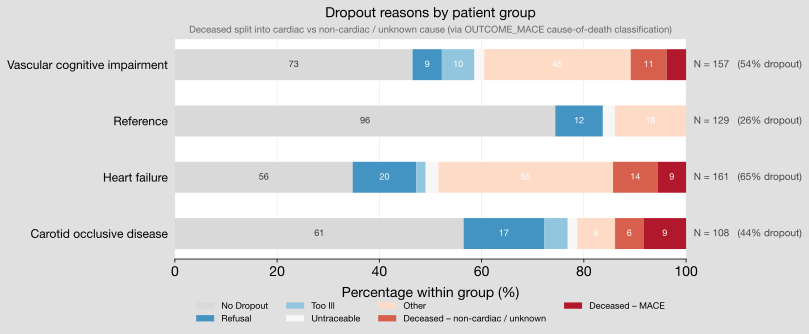

In [18]:
# Dropout reasons by patient group — stacked 100% bar chart.
# "Deceased" in DROPOUT REASON is all-cause mortality. We split it into
# cardiac vs non-cardiac/unknown-cause death using OUTCOME_MACE, which
# flags death as cardiac when the cause-of-death text matched MACE terms
# (myocardinfarct, hartstilstand, hartfalen, CVA, etc.) during preprocessing.

GROUP_COL   = 'PATIENT GROUP'
DROPOUT_COL = 'DROPOUT REASON'
MACE_COL    = 'OUTCOME_MACE'

reason_detail = df_imp[DROPOUT_COL].astype(str).copy()
deceased   = reason_detail.str.casefold() == 'deceased'
cardiac    = deceased & (df_imp[MACE_COL].astype(str) == 'Yes')
noncardiac = deceased & ~cardiac

reason_detail[cardiac]    = 'Deceased – MACE'
reason_detail[noncardiac] = 'Deceased – non-cardiac / unknown'

reason_order = [r for r in (
    'No Dropout',
    'Refusal',
    'Too Ill',
    'Moved to Nursing Home',
    'Untraceable',
    'Other',
    'Deceased – non-cardiac / unknown',
    'Deceased – MACE',
) if r in set(reason_detail)]

dropout_raw  = (pd.crosstab(df_imp[GROUP_COL], reason_detail)
                  .reindex(columns=reason_order, fill_value=0))
dropout_norm = dropout_raw.div(dropout_raw.sum(axis=1), axis=0).mul(100)

# Semantic palette: neutral grey for "No Dropout", cool colours for
# non-death dropout, warm reds for death (deepest red = cardiac).
color_map = {
    'No Dropout':                       '#d9d9d9',   # neutral grey (outside RdBu)
    'Refusal':                          '#4393c3',   # RdBu blue
    'Too Ill':                          '#92c5de',   # RdBu light blue
    'Moved to Nursing Home':            '#d1e5f0',   # RdBu pale blue
    'Untraceable':                      '#f7f7f7',   # RdBu midpoint (near-white)
    'Other':                            '#fddbc7',   # RdBu pale red
    'Deceased – non-cardiac / unknown': '#d6604d',   # RdBu red
    'Deceased – MACE':               '#b2182b',   # RdBu dark red
}

groups = dropout_raw.index.tolist()
y      = np.arange(len(groups))
bar_h  = 0.55

fig, ax = plt.subplots(figsize=(11.5, max(3.2, len(groups) * 0.75 + 2)))

lefts = np.zeros(len(groups))
for reason in reason_order:
    vals   = dropout_norm[reason].values
    counts = dropout_raw[reason].values
    ax.barh(y, vals, left=lefts, height=bar_h,
            color=color_map.get(reason, '#cccccc'),
            label=reason, linewidth=0)
    for j, (v, n) in enumerate(zip(vals, counts)):
        if v >= 5 and n > 0:
            text_color = '#333333' if reason == 'No Dropout' else 'white'
            ax.text(lefts[j] + v / 2, j, f'{int(n)}',
                    ha='center', va='center',
                    fontsize=9, color=text_color)
    lefts += vals

# Group totals: overall N and % dropped out.
for j, grp in enumerate(groups):
    n_total  = int(dropout_raw.loc[grp].sum())
    n_nodrop = int(dropout_raw.loc[grp].get('No Dropout', 0))
    pct_drop = 100 * (n_total - n_nodrop) / n_total if n_total else 0
    ax.text(101.5, j,
            f'N = {n_total}   ({pct_drop:.0f}% dropout)',
            va='center', fontsize=10, color='#444444', clip_on=False)

ax.set_yticks(y)
ax.set_yticklabels(groups, fontsize=12)
ax.set_xlim(0, 100)
ax.set_xlabel('Percentage within group (%)', labelpad=8)
ax.set_title('Dropout reasons by patient group', fontsize=14, pad=22)
ax.text(0.5, 1.03,
        'Deceased split into cardiac vs non-cardiac / unknown cause '
        '(via OUTCOME_MACE cause-of-death classification)',
        transform=ax.transAxes, ha='center',
        fontsize=9.5, color='#666666')

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
ax.xaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16),
          ncol=min(len(reason_order), 4),
          frameon=False, fontsize=9)

plt.tight_layout()

fig.savefig(OUTPUT_GRAPHS_DIR / 'dropout_by_patient_group.pdf', bbox_inches='tight')
print(f"Saved: {OUTPUT_GRAPHS_DIR / 'dropout_by_patient_group.pdf'}")

plt.show()

### 2.1b Alluvial plots — patient flow across timepoints

Visualise how patients transition between outcome states and dropout categories
from baseline (T0) through two-year (T2) and four-year (T4) follow-up.
One plot per outcome: **CDR increase** and **MACE**.

In [20]:
# Load per-timepoint outcome states (saved by 00_preprocess.ipynb)
df_outcome_states = pd.read_parquet(DATA_DIR / 'df_outcome_states.parquet', engine='pyarrow')
print(f'Loaded df_outcome_states: {df_outcome_states.shape}')

Loaded df_outcome_states: (566, 9)


In [21]:
import matplotlib.patches as mpatches
from matplotlib.path import Path as MplPath


def _draw_band(ax, x0, y0_bot, y0_top, x1, y1_bot, y1_top, color, alpha=0.45):
    """Draw a curved band (Bezier) between two vertical segments."""
    xm = (x0 + x1) / 2
    verts = [
        (x0, y0_bot),                          # start bottom-left
        (xm, y0_bot), (xm, y1_bot), (x1, y1_bot),  # cubic Bezier bottom edge
        (x1, y1_top),                          # line up on right
        (xm, y1_top), (xm, y0_top), (x0, y0_top),  # cubic Bezier top edge back
        (x0, y0_bot),                          # close
    ]
    codes = [
        MplPath.MOVETO,
        MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
        MplPath.CLOSEPOLY,
    ]
    path = MplPath(verts, codes)
    patch = mpatches.PathPatch(path, facecolor=color, alpha=alpha,
                               edgecolor='none', linewidth=0)
    ax.add_patch(patch)


def alluvial_plot(df, columns, timepoint_labels, title, state_order,
                  state_colors, figsize=(13, 7)):
    """
    Draw an alluvial (Sankey-style) plot showing patient flows across timepoints.

    Parameters
    ----------
    df : DataFrame with one column per timepoint holding categorical state labels.
    columns : list of column names for each timepoint (left to right).
    timepoint_labels : display labels for the x-axis.
    title : plot title.
    state_order : list defining top-to-bottom stacking order of states.
    state_colors : dict mapping state label -> colour.
    """
    fig, ax = plt.subplots(figsize=figsize)
    n_tp = len(columns)
    x_pos = np.arange(n_tp, dtype=float)
    bar_w = 0.22
    total = len(df)
    gap_frac = 0.006          # vertical gap between stacked segments

    # --- compute stacked bar geometry at each timepoint -----------------------
    bar_geom = {}             # {tp_idx: [(state, count, y_bot, y_top), ...]}
    for ti, col in enumerate(columns):
        counts = df[col].value_counts()
        ordered = [s for s in state_order if s in counts.index]
        y = 0.0
        segments = []
        for state in ordered:
            h = counts[state]
            segments.append((state, h, y, y + h))
            y += h + total * gap_frac
        bar_geom[ti] = segments

    # --- draw bars ------------------------------------------------------------
    for ti in range(n_tp):
        for state, count, yb, yt in bar_geom[ti]:
            color = state_colors.get(state, '#cccccc')
            rect = plt.Rectangle((x_pos[ti] - bar_w / 2, yb), bar_w, yt - yb,
                                  facecolor=color, edgecolor='white', linewidth=0.6)
            ax.add_patch(rect)
            if (yt - yb) > total * 0.025:
                label = state if len(state) <= 22 else state[:20] + '\u2026'
                ax.text(x_pos[ti], (yb + yt) / 2,
                        f'{label}\nn={count}',
                        ha='center', va='center', fontsize=7.5,
                        color='white' if _luminance(color) < 0.55 else '#333333')

    # --- draw flow bands between adjacent timepoints -------------------------
    for ti in range(n_tp - 1):
        col_from, col_to = columns[ti], columns[ti + 1]
        ct = pd.crosstab(df[col_from], df[col_to])
        src_off = {s: yb for s, _, yb, _ in bar_geom[ti]}
        tgt_off = {s: yb for s, _, yb, _ in bar_geom[ti + 1]}
        for src_state, _, _, _ in bar_geom[ti]:
            for tgt_state, _, _, _ in bar_geom[ti + 1]:
                if src_state not in ct.index or tgt_state not in ct.columns:
                    continue
                flow = ct.loc[src_state, tgt_state]
                if flow == 0:
                    continue
                color = state_colors.get(src_state, '#cccccc')
                _draw_band(ax,
                           x_pos[ti] + bar_w / 2,
                           src_off[src_state], src_off[src_state] + flow,
                           x_pos[ti + 1] - bar_w / 2,
                           tgt_off[tgt_state], tgt_off[tgt_state] + flow,
                           color=color, alpha=0.38)
                src_off[src_state] += flow
                tgt_off[tgt_state] += flow

    # --- axes ----------------------------------------------------------------
    max_y = max(yt for segs in bar_geom.values() for _, _, _, yt in segs)
    ax.set_xlim(-0.5, n_tp - 0.5)
    ax.set_ylim(-total * 0.02, max_y + total * 0.02)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(timepoint_labels, fontsize=13)
    ax.set_title(title, fontsize=14, pad=14)
    ax.set_ylabel('Number of patients', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)

    # --- legend (outside plot) -----------------------------------------------
    present = {s for col in columns for s in df[col].unique()}
    handles = [mpatches.Patch(color=state_colors.get(s, '#ccc'), label=s)
               for s in state_order if s in present]
    ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1),
              frameon=False, fontsize=9)
    plt.tight_layout()
    return fig


def _luminance(color):
    """Approximate relative luminance for text contrast."""
    import matplotlib.colors as mcolors
    r, g, b, *_ = mcolors.to_rgba(color)
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

Saved: <PROJECT_ROOT>/outputs/graphs/alluvial_cdr.pdf


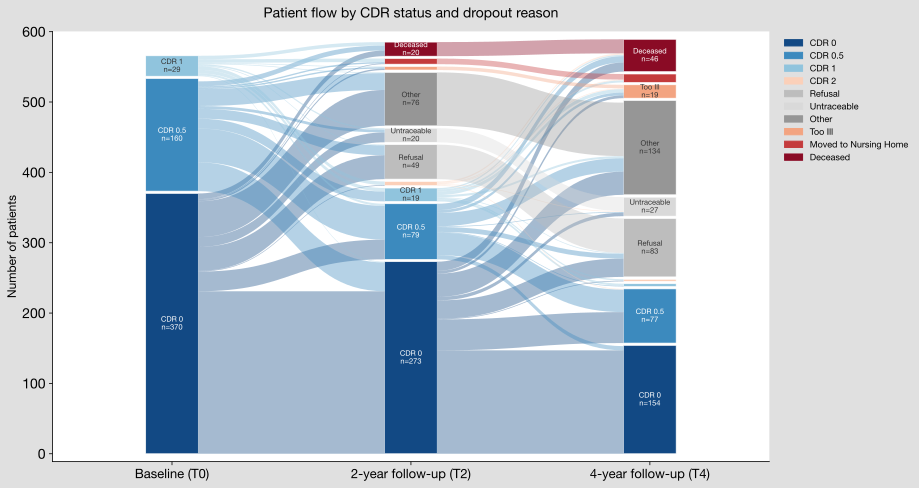

In [22]:
# ── Alluvial plot: CDR outcome ─────────────────────────────────────────────
cmap = plt.cm.RdBu

# Build per-timepoint state columns
dst = df_outcome_states.copy()

def _cdr_label(val):
    if pd.isna(val):
        return None
    v = float(val)
    return f'CDR {v:g}'

dst['T0_state'] = dst['T0_CDR'].apply(_cdr_label)

# T2: CDR state if participating, else dropout reason
dst['T2_state'] = np.where(
    dst['T2_dropout_reason'] != 'No Dropout',
    dst['T2_dropout_reason'],
    dst['T2_CDR'].apply(_cdr_label)
)

# T4: if already dropped at T2 carry forward; else check T4 dropout; else CDR
dst['T4_state'] = np.where(
    dst['T2_dropout_reason'] != 'No Dropout',
    dst['T2_dropout_reason'],             # still out from T2
    np.where(
        dst['T4_dropout_reason'] != 'No Dropout',
        dst['T4_dropout_reason'],         # dropped at T4
        dst['T4_CDR'].apply(_cdr_label)   # still participating
    )
)

# Drop rows with missing baseline CDR
dst = dst.dropna(subset=['T0_state'])

# State ordering: CDR levels first (good → bad), then dropout reasons
cdr_state_order = [
    'CDR 0', 'CDR 0.5', 'CDR 1', 'CDR 1.5', 'CDR 2', 'CDR 3',
    'Refusal', 'Untraceable', 'Other',
    'Too Ill', 'Moved to Nursing Home', 'Deceased',
]

cdr_state_colors = {
    'CDR 0':                   cmap(0.95),
    'CDR 0.5':                 cmap(0.82),
    'CDR 1':                   cmap(0.70),
    'CDR 1.5':                 cmap(0.58),
    'CDR 2':                   cmap(0.38),
    'CDR 3':                   cmap(0.22),
    'Refusal':                 '#bdbdbd',
    'Untraceable':             '#d9d9d9',
    'Other':                   '#969696',
    'Too Ill':                 cmap(0.30),
    'Moved to Nursing Home':   cmap(0.15),
    'Deceased':                cmap(0.05),
}

fig_cdr = alluvial_plot(
    dst,
    columns=['T0_state', 'T2_state', 'T4_state'],
    timepoint_labels=['Baseline (T0)', '2-year follow-up (T2)', '4-year follow-up (T4)'],
    title='Patient flow by CDR status and dropout reason',
    state_order=cdr_state_order,
    state_colors=cdr_state_colors,
)
fig_cdr.savefig(OUTPUT_GRAPHS_DIR / 'alluvial_cdr.pdf', bbox_inches='tight')
print(f'Saved: {OUTPUT_GRAPHS_DIR / "alluvial_cdr.pdf"}')
plt.show()

Saved: <PROJECT_ROOT>/outputs/graphs/alluvial_mace.pdf


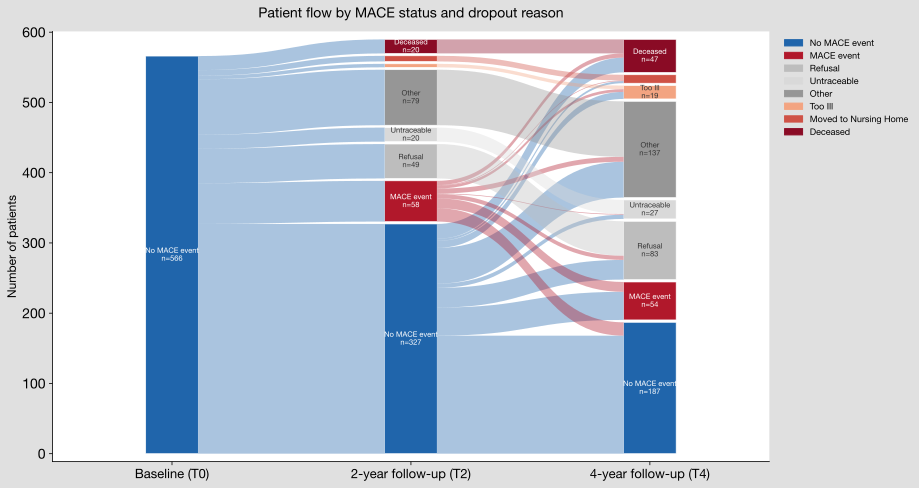

In [23]:
# ── Alluvial plot: MACE outcome ────────────────────────────────────────────
dstm = df_outcome_states.copy()

def _mace_label(val):
    if pd.isna(val):
        return 'No MACE event'
    return 'MACE event' if int(val) == 1 else 'No MACE event'

dstm['T0_state'] = dstm['T0_Event_MACE'].apply(_mace_label)

dstm['T2_state'] = np.where(
    dstm['T2_dropout_reason'] != 'No Dropout',
    dstm['T2_dropout_reason'],
    dstm['T2_Event_MACE'].apply(_mace_label)
)

dstm['T4_state'] = np.where(
    dstm['T2_dropout_reason'] != 'No Dropout',
    dstm['T2_dropout_reason'],
    np.where(
        dstm['T4_dropout_reason'] != 'No Dropout',
        dstm['T4_dropout_reason'],
        dstm['T4_Event_MACE'].apply(_mace_label)
    )
)

mace_state_order = [
    'No MACE event', 'MACE event',
    'Refusal', 'Untraceable', 'Other',
    'Too Ill', 'Moved to Nursing Home', 'Deceased',
]

mace_state_colors = {
    'No MACE event':           cmap(0.90),
    'MACE event':              cmap(0.10),
    'Refusal':                 '#bdbdbd',
    'Untraceable':             '#d9d9d9',
    'Other':                   '#969696',
    'Too Ill':                 cmap(0.30),
    'Moved to Nursing Home':   cmap(0.18),
    'Deceased':                cmap(0.05),
}

fig_mace = alluvial_plot(
    dstm,
    columns=['T0_state', 'T2_state', 'T4_state'],
    timepoint_labels=['Baseline (T0)', '2-year follow-up (T2)', '4-year follow-up (T4)'],
    title='Patient flow by MACE status and dropout reason',
    state_order=mace_state_order,
    state_colors=mace_state_colors,
)
fig_mace.savefig(OUTPUT_GRAPHS_DIR / 'alluvial_mace.pdf', bbox_inches='tight')
print(f'Saved: {OUTPUT_GRAPHS_DIR / "alluvial_mace.pdf"}')
plt.show()

### 2.2 Metadata sanity check
The `bn_vars` table should map every variable used in the network to its corresponding layer.
If you add new variables, ensure the parquet file lists them with the desired `LAYER` label.

Example `bn_vars.parquet` structure (first columns):

| LAYER | VARIABLE NAME | DESCRIPTION |
| --- | --- | --- |
| L0 – Unmodifiable demographics | AGE | Baseline age in years |
| L0 – Unmodifiable demographics | SEX | Biological sex at baseline |
| L2 – Cardiovascular risk factors | VASCULAR RISK SCORE | SCORE2 cardiovascular risk estimate |
| L4 – Potential disease process markers | PTAU181 | Plasma pTau181 concentration category |
| L6 – Current and previous cardiovascular diagnoses / Vascular interventions | PATIENT GROUP | Diagnostic cohort label |
| L8 – Outcomes | OUTCOME_MACE | Binary indicator of follow-up MACE |

Add extra columns (e.g. `DISPLAY NAME`, `NOTES`) as needed—the loader only requires `LAYER` and `VARIABLE NAME`.

In [24]:
# Ensure DROPOUT REASON is mapped to the dropout layer
if 'bn_vars' in globals():
    if 'DROPOUT REASON' not in bn_vars['VARIABLE NAME'].values:
        bn_vars = pd.concat([bn_vars, pd.DataFrame([{'LAYER': 'L9 – Dropout', 'VARIABLE NAME': 'DROPOUT REASON'}])], ignore_index=True)
    else:
        bn_vars.loc[bn_vars['VARIABLE NAME'] == 'DROPOUT REASON', 'LAYER'] = 'L9 – Dropout'


In [25]:
# Preview the first few rows once bn_vars.parquet is loaded
bn_vars.sort_values(['LAYER', 'VARIABLE NAME'])

,LAYER,VARIABLE NAME
12,L0 – Unmodifiable demographics,AGE
13,L0 – Unmodifiable demographics,SEX
21,L2 – Cardiovascular risk factors,VASCULAR RISK SCORE
18,L4 – Potential disease process markers,AB40
19,L4 – Potential disease process markers,AB42
4,L4 – Potential disease process markers,BIOMARKER SCORE 1
5,L4 – Potential disease process markers,BIOMARKER SCORE 2
9,L4 – Potential disease process markers,CEREBRAL BLOOD FLOW
16,L4 – Potential disease process markers,GFAP
15,L4 – Potential disease process markers,NFL


In [26]:
# Validate the metadata layout before building the network
expected_columns = {'LAYER', 'VARIABLE NAME'}
missing_cols = expected_columns - set(bn_vars.columns)
if missing_cols:
    raise ValueError(f"bn_vars is missing required columns: {missing_cols}")

print('Layers discovered in bn_vars:', sorted(bn_vars['LAYER'].unique()))
display(bn_vars.head())


Layers discovered in bn_vars: ['L0 – Unmodifiable demographics', 'L2 – Cardiovascular risk factors', 'L4 – Potential disease process markers', 'L5 - Imaging markers of neurovascular damage', 'L6 – Current and previous cardiovascular diagnoses / Vascular interventions', 'L7 - Functional status', 'L8 – Outcomes', 'L9 – Dropout']


,LAYER,VARIABLE NAME
0,L7 - Functional status,MINI MENTAL STATE EXAMINATION
1,L7 - Functional status,STARKSTEIN SCORE
2,L7 - Functional status,BASELINE CDR
3,L6 – Current and previous cardiovascular diagn...,STROKE HISTORY
4,L4 – Potential disease process markers,BIOMARKER SCORE 1


## 3. Variable Discretisation

Configure the binning strategy feeding each learner and inspect the resulting template.

In [27]:
# Configure discretisation defaults for mixed-type clinical variables
# (spec.yml -> discretisation)
type_processor = DiscreteTypeProcessor(
  defaultDiscretizationMethod=SPEC.discretisation.method,
  defaultNumberOfBins=SPEC.discretisation.n_bins,
  discretizationThreshold=SPEC.discretisation.threshold,
)


In [28]:
# Inspect the discretised template to document the bins used by the learner
# creating a template explaining the variables proposed by the type_processor. This variables will be used by the learner
template = type_processor.discretizedTemplate(df_imp)
for i, n in template:
  print(f"{n:7} : {template.variable(i)}")

AGE     : AGE:Discretized(<(48.4928;61.5777[,[61.5777;68.0452[,[68.0452;73.6283[,[73.6283;92.4983)>)
SEX     : SEX:Labelized({Female|Male})
PTAU181 : PTAU181:Discretized(<(-1.09822;1.2385[,[1.2385;1.57184[,[1.57184;2.20784[,[2.20784;11.0239)>)
NFL     : NFL:Discretized(<(-34.9341;13.3083[,[13.3083;18.2215[,[18.2215;26.5476[,[26.5476;309.426)>)
GFAP    : GFAP:Discretized(<(-4.02821;67.0368[,[67.0368;94.8627[,[94.8627;134.737[,[134.737;676.236)>)
AB40    : AB40:Discretized(<(8.19715;87.4806[,[87.4806;100.048[,[100.048;112.567[,[112.567;263.656)>)
AB42    : AB42:Discretized(<(0.510692;5.60809[,[5.60809;6.52764[,[6.52764;7.61622[,[7.61622;17.5025)>)
MINI MENTAL STATE EXAMINATION : MINI MENTAL STATE EXAMINATION:Discretized(<(15;27[,[27;29[,[29;30)>)
STARKSTEIN SCORE : STARKSTEIN SCORE:Discretized(<(0;7[,[7;9[,[9;12[,[12;32)>)
BASELINE CDR : BASELINE CDR:NumericalDiscrete({0|0.5|1})
STROKE HISTORY : STROKE HISTORY:Labelized({No|Yes, hemorrhagic stroke|Yes, ischemic stroke|Yes, type unknown})

In [29]:
# Inspect the discretised template to document the bins used by the learner
# `format_label` is `core.discretisation.format_bin_label` (imported in
# cell 2) — same output for interval labels. See PORT_DIFF.md §20.
template = type_processor.discretizedTemplate(df_imp)

for i, n in template:
    var = template.variable(i)
    labels = var.labels()

    # Check if the labels look like intervals
    if all((";" in label and "[" in label) for label in labels):
        formatted_labels = [format_label(label) for label in labels]
        print(f"{n:7} : {formatted_labels}")
    else:
        print(f"{n:7} : {labels}")


AGE     : ['(48.5;61.6[', '(61.6;68.0[', '(68.0;73.6[', '(73.6;92.5[']
SEX     : ('Female', 'Male')
PTAU181 : ['(-1.1;1.2[', '(1.2;1.6[', '(1.6;2.2[', '(2.2;11.0[']
NFL     : ['(-34.9;13.3[', '(13.3;18.2[', '(18.2;26.5[', '(26.5;309.4[']
GFAP    : ['(-4.0;67.0[', '(67.0;94.9[', '(94.9;134.7[', '(134.7;676.2[']
AB40    : ['(8.2;87.5[', '(87.5;100.0[', '(100.0;112.6[', '(112.6;263.7[']
AB42    : ['(0.5;5.6[', '(5.6;6.5[', '(6.5;7.6[', '(7.6;17.5[']
MINI MENTAL STATE EXAMINATION : ['(15.0;27.0[', '(27.0;29.0[', '(29.0;30.0[']
STARKSTEIN SCORE : ['(0.0;7.0[', '(7.0;9.0[', '(9.0;12.0[', '(12.0;32.0[']
BASELINE CDR : ('0', '0.5', '1')
STROKE HISTORY : ('No', 'Yes, hemorrhagic stroke', 'Yes, ischemic stroke', 'Yes, type unknown')
SMALL VESSEL DISEASE SCORE : ['(0.0;1.0[', '(1.0;2.0[', '(2.0;4.0[']
BIOMARKER SCORE 1 : ['(-1.7;-0.3[', '(-0.3;0.0[', '(0.0;0.4[', '(0.4;3.9[']
BIOMARKER SCORE 2 : ['(-11.1;-0.4[', '(-0.4;0.1[', '(0.1;0.6[', '(0.6;13.5[']
HIPPOCAMPUS/INTRACRANIAL VOLUME : ['(0.1;0.1

In [30]:
# Optional: uncomment to audit discretisation results
#auditDict = type_processor.audit(df_imp)

#print()
#print("** audit **")
#for var in auditDict:
#  print(f"- {var} : ")
#  for k, v in auditDict[var].items():
#    print(f"    + {k} : {v}")

## 4. Knowledge-Guided Network Definition

Translate the expert-defined layers into a reusable Bayesian network template.

In [31]:
# Map variables onto expert-defined layers for downstream constraints.
# (spec.yml -> layers).  Previously this was
# `bn_vars.groupby('LAYER')['VARIABLE NAME'].apply(list).to_dict()`, whose
# key order was alphabetical rather than domain-defined. The spec fixes the
# order explicitly, and that order IS the arc constraint.
layer_map = SPEC.layer_map


In [32]:
# Instantiate the Bayesian network using the discretised template as blueprint
bn = gum.BayesNet("LayeredBN")
node_ids = {}

for i in range(template.size()):
    var = template.variable(i)
    name = var.name()
    node_ids[name] = bn.add(var)  # only add once, from template
    

In [33]:
# Preserve the expert-defined order of layers when applying constraints
# Make sure keys are in the correct order
layer_keys = list(layer_map.keys())  # use list, not sorted, to preserve domain-defined order

## 5. Constrained Structure Learning

Estimate networks that respect the layer order while testing different outcome configurations.

In [34]:

# Utility: learn a Bayesian network with optional guided structure constraints
#
# `build_bn` and `configure_guided_structure` come from `core.bn_utils`
# (imported in cell 2). Every value below is read from spec.yml.
# See PORT_DIFF.md §21-22 and SPEC_PLAN.md.

HBC_EXCLUDE_LAYERS = list(SPEC.variant("joint").exclude_layers)

# Outcome/dropout layers are identified from the spec's `role:` fields
# rather than by substring-matching the layer name.
LAYER_ROLE_PATTERNS = dict(
    outcome_patterns=SPEC.outcome_patterns,
    dropout_patterns=SPEC.dropout_patterns,
)

# Learner settings (spec.yml -> model).
LEARN_KWARGS = dict(
    score=SPEC.model.score,
    use_tabu=SPEC.model.use_tabu,
    max_indegree=SPEC.model.max_indegree,
    random_seed=SPEC.model.seed,
    **LAYER_ROLE_PATTERNS,
)

# Scenario evidence, keyed by profile name (spec.yml -> analyses.scenarios).
SCENARIO_EVS = dict(SPEC.scenarios.profiles)


In [35]:
bn_cdr = build_bn(df_imp, outcomes=list(SPEC.variant("cdr").outcomes), layer_map=layer_map, type_processor=type_processor, exclude_layers=list(SPEC.variant("cdr").exclude_layers), **LEARN_KWARGS)
bn_mace = build_bn(df_imp, outcomes=list(SPEC.variant("mace").outcomes), layer_map=layer_map, type_processor=type_processor, exclude_layers=list(SPEC.variant("mace").exclude_layers), **LEARN_KWARGS)
bn_joint = build_bn(df_imp, outcomes=list(SPEC.variant("joint").outcomes), layer_map=layer_map, type_processor=type_processor, exclude_layers=list(SPEC.variant("joint").exclude_layers), **LEARN_KWARGS)


In [36]:
# Define your ordered layers and assign them increasing color intensity
layer_order = [
    'L0 – Unmodifiable demographics',
    'L1 – Modifiable demograhpics / Lifestyle factors',
    'L2 – Cardiovascular risk factors',
    'L4 – Potential disease process markers',
    'L5 - Imaging markers of neurovascular damage',
    'L6 – Current and previous cardiovascular diagnoses / Vascular interventions',
    'L7 - Functional status',
    'L8 – Outcomes',
    'L9 – Dropout'
]

# Set adjusted min and max color values
min_color_val = 0.111111
max_color_val = 0.99999
steps = len(layer_order) - 1

# Create adjusted color intensity map
layer_color_map = {
    name: min_color_val + i * (max_color_val - min_color_val) / steps
    for i, name in enumerate(layer_order)
}

# Build the nodeColor dictionary
node_colors = {}
for layer_name, variables in layer_map.items():
    color_val = layer_color_map.get(layer_name, 0.5)  # fallback if unknown
    for var in variables:
        if var in bn_joint.names():
            node_colors[var] = color_val

In [37]:
# Bootstrap helper: quantify edge stability across resampled datasets
#
# `bootstrap_edge_frequencies` now comes from `core.bn_utils` (imported in
# cell 2). core was updated to divide by `n_bootstraps` rather than by the
# number of successful fits, matching this notebook. See PORT_DIFF.md §23.


In [38]:
edge_freqs = bootstrap_edge_frequencies(
    df=df_imp,
    outcomes=list(SPEC.variant("joint").outcomes),
    layer_map=layer_map,
    type_processor=type_processor,
    build_bn_func=build_bn,
    exclude_layers=HBC_EXCLUDE_LAYERS,
    n_bootstraps=SPEC.bootstrap_for("joint"),
    **LEARN_KWARGS
)

# Print top edges
for edge, freq in sorted(edge_freqs.items(), key=lambda x: -x[1]):
    print(f"{edge[0]} → {edge[1]}: {freq:.2f}")


PATIENT GROUP → BASELINE CDR: 1.00
OUTCOME_MACE → DROPOUT REASON: 1.00
AGE → VASCULAR RISK SCORE: 1.00
PATIENT GROUP → OUTCOME_CDR_INCREASE: 1.00
OUTCOME_CDR_INCREASE → DROPOUT REASON: 1.00
SEX → VASCULAR RISK SCORE: 1.00
SMALL VESSEL DISEASE SCORE → PATIENT GROUP: 0.99
VASCULAR RISK SCORE → SMALL VESSEL DISEASE SCORE: 0.98
BASELINE CDR → MINI MENTAL STATE EXAMINATION: 0.97
AGE → HIPPOCAMPUS/INTRACRANIAL VOLUME: 0.97
VASCULAR RISK SCORE → BRAIN/INTRACRANIAL VOLUME: 0.95
AGE → BRAIN/INTRACRANIAL VOLUME: 0.93
VASCULAR RISK SCORE → HIPPOCAMPUS/INTRACRANIAL VOLUME: 0.93
SEX → HIPPOCAMPUS/INTRACRANIAL VOLUME: 0.92
SEX → ATHEROSCLEROTIC CARDIOVASCULAR DISEASE HISTORY: 0.85
PATIENT GROUP → STARKSTEIN SCORE: 0.81
BASELINE CDR → STARKSTEIN SCORE: 0.74
BRAIN/INTRACRANIAL VOLUME → HIPPOCAMPUS/INTRACRANIAL VOLUME: 0.70
PATIENT GROUP → OUTCOME_MACE: 0.69
BRAIN/INTRACRANIAL VOLUME → STARKSTEIN SCORE: 0.66
AGE → SMALL VESSEL DISEASE SCORE: 0.65
SEX → BRAIN/INTRACRANIAL VOLUME: 0.62
SMALL VESSEL DISEA

In [39]:
# Get the labels for CDR_INCR
cdr_labels = list(bn_joint.variable(bn_joint.idFromName("OUTCOME_CDR_INCREASE")).labels())
mace_labels = list(bn_joint.variable(bn_joint.idFromName("OUTCOME_MACE")).labels())

## 6. Posterior Inference and Edge Stability

Summarise how the learned networks behave under different evidence configurations and assess structural robustness.

### 6.1 Posterior inference for CDR

Visualise how upstream factors shift when conditioning on `OUTCOME_CDR_INCREASE`.

Condition the CDR network on each outcome modality to review the upstream clinical drivers.

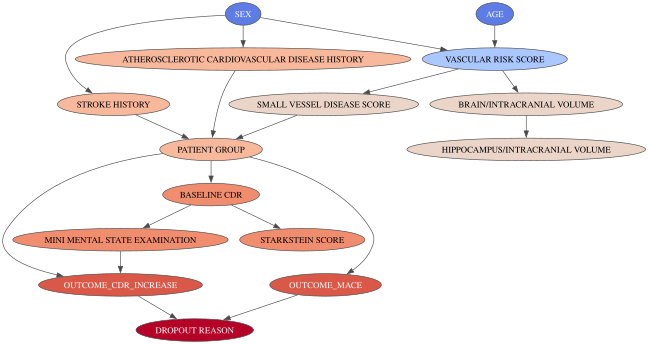

NoneInference given that CDR_INCREASE = No


Saved BN PDFs to <PROJECT_ROOT>/outputs/graphs


In [40]:
gnb.sideBySide(
    *[
        gnb.showBN(bn_joint, size="9", nodeColor=node_colors, cmapNode=plt.get_cmap("coolwarm"))
    ],
    captions=[f"Inference given that CDR_INCREASE = {label}" for label in cdr_labels],
    ncols=1
)

# Save as PDF (editable in Illustrator)
for label in cdr_labels:
    gumimage.export(
        bn_joint,
        str(OUTPUT_GRAPHS_DIR / f'bn_joint_cdr_{label}.pdf'),
        nodeColor=node_colors,
        cmapNode=plt.get_cmap("coolwarm"),
    )
print(f"Saved BN PDFs to {OUTPUT_GRAPHS_DIR}")


### 6.2 Joint inference for CDR and MACE

Inspect posterior behaviour when conditioning on both outcome nodes simultaneously.

Focus on the parents of each outcome to summarise the conditional probability tables.

In [41]:
# Create inference engine
ie = gum.LazyPropagation(bn_joint)
ie.makeInference()

# Compute MI and apply it to arcs using variable indices (not names)
arc_width = {}

for u, v in bn_joint.arcs():  # u and v are variable IDs
    try:
        it = gum.InformationTheory(ie, v, [u])  # use IDs directly
        mi = it.mutualInformationXY()
    except:
        mi = 0.1

    arc_width[(u, v)] = mi  # ✅ use indices, not names

max_mi = max(arc_width.values())
arc_width = {k: (np.sqrt(v) / np.sqrt(max_mi) * 3.0 + 0.5) for k, v in arc_width.items()}


In [42]:
var_name_to_id = {bn_joint.variable(i).name(): i for i in range(bn_joint.size())}

bootstrap_freq_id = {}

for (parent_name, child_name), freq in edge_freqs.items():
    try:
        parent_id = var_name_to_id[parent_name]
        child_id = var_name_to_id[child_name]
        bootstrap_freq_id[(parent_id, child_id)] = freq
    except KeyError:
        continue  # skip if variable not found in network

In [43]:
arc_label = {
    arc: f"f={int(bootstrap_freq_id.get(arc, 0.0) * 100)}%"
    for arc in bn_joint.arcs()
}

In [44]:
arc_label

{(13, 8): 'f=95%',
 (14, 4): 'f=100%',
 (4, 3): 'f=74%',
 (1, 5): 'f=12%',
 (0, 13): 'f=100%',
 (8, 7): 'f=70%',
 (6, 14): 'f=99%',
 (5, 14): 'f=50%',
 (14, 10): 'f=69%',
 (4, 2): 'f=97%',
 (11, 12): 'f=100%',
 (1, 13): 'f=100%',
 (10, 12): 'f=100%',
 (13, 6): 'f=98%',
 (9, 14): 'f=50%',
 (2, 11): 'f=59%',
 (1, 9): 'f=85%',
 (14, 11): 'f=100%'}

In [45]:
arc_color_values = {
    arc: bootstrap_freq_id.get(arc, 0.0)
    for arc in bn_joint.arcs()
}


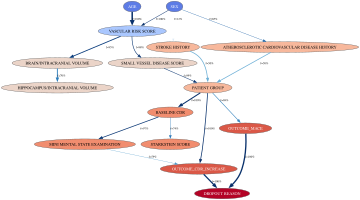

Saved: <PROJECT_ROOT>/outputs/graphs/bn_joint_structure.pdf


In [46]:
# Plot with MI-based edge widths
gnb.showBN(
    bn_joint,
    arcWidth=arc_width,
    nodeColor=node_colors,
    arcColor=arc_color_values,
    arcLabel=arc_label,
    cmapNode=plt.get_cmap("coolwarm"),
    cmapArc=plt.get_cmap("Blues")
)

# Save as PDF (editable in Illustrator)
gumimage.export(
    bn_joint,
    str(OUTPUT_GRAPHS_DIR / 'bn_joint_structure.pdf'),
    arcWidth=arc_width,
    nodeColor=node_colors,
    arcColor=arc_color_values,
    arcLabel=arc_label,
    cmapNode=plt.get_cmap("coolwarm"),
    cmapArc=plt.get_cmap("Blues"),
)
print(f"Saved: {OUTPUT_GRAPHS_DIR / 'bn_joint_structure.pdf'}")


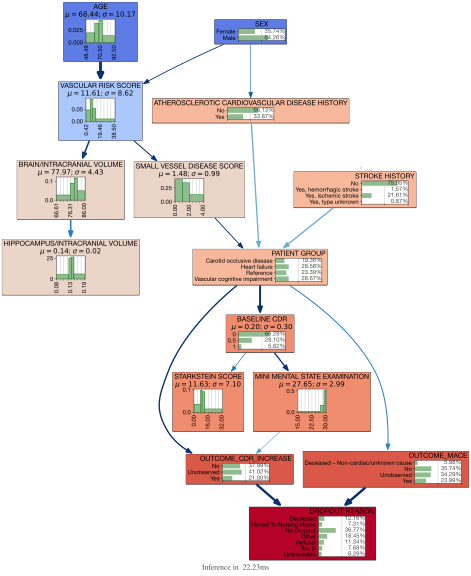

OSError: no library called "cairo-2" was found
no library called "cairo" was found
no library called "libcairo-2" was found
cannot load library 'libcairo.so.2': dlopen(libcairo.so.2, 0x0002): tried: 'libcairo.so.2' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibcairo.so.2' (no such file), '/usr/lib/libcairo.so.2' (no such file, not in dyld cache), 'libcairo.so.2' (no such file).  Additionally, ctypes.util.find_library() did not manage to locate a library called 'libcairo.so.2'
cannot load library 'libcairo.2.dylib': dlopen(libcairo.2.dylib, 0x0002): tried: 'libcairo.2.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibcairo.2.dylib' (no such file), '/usr/lib/libcairo.2.dylib' (no such file, not in dyld cache), 'libcairo.2.dylib' (no such file).  Additionally, ctypes.util.find_library() did not manage to locate a library called 'libcairo.2.dylib'
cannot load library 'libcairo-2.dll': dlopen(libcairo-2.dll, 0x0002): tried: 'libcairo-2.dll' (no such file), '/System/Vo

In [47]:
# Plot with MI-based edge widths
gnb.showInference(
    bn_joint,
    arcWidth=arc_width,
    nodeColor=node_colors,
    arcColor=arc_color_values,
    cmapNode=plt.get_cmap("coolwarm"),
    cmapArc=plt.get_cmap("Blues")
)

# Save as PDF (editable in Illustrator)
gumimage.exportInference(
    bn_joint,
    str(OUTPUT_GRAPHS_DIR / 'bn_joint_inference.pdf'),
    arcWidth=arc_width,
    nodeColor=node_colors,
    arcColor=arc_color_values,
    cmapNode=plt.get_cmap("coolwarm"),
    cmapArc=plt.get_cmap("Blues"),
)
print(f"Saved: {OUTPUT_GRAPHS_DIR / 'bn_joint_inference.pdf'}")


Here, the whole network is considered

In [48]:
gnb.sideBySide(
  "<H3>OUTCOME CDR INCREASE</H3>",
  "<H3>OUTCOME MACE</H3>",
  bn_joint.cpt("OUTCOME_CDR_INCREASE"),
  bn_joint.cpt("OUTCOME_MACE"),
  ncols=2,
)

### 6.3 Uncorrected mutual information — CDR_INCREASE

In [49]:
# Initialize inference engine
ie = gum.LazyPropagation(bn_joint)

# Get all variables in the network except the outcome
all_variables = bn_joint.names()
variables_to_test = [var for var in all_variables if var != 'OUTCOME_CDR_INCREASE']

# Store results
mi_results = {}

for var in variables_to_test:
    try:
        it = gum.InformationTheory(ie, 'OUTCOME_CDR_INCREASE', [var])
        mi = it.mutualInformationXY()  # Without correction
        mi_results[var] = mi
        print(f'Mutual Information ({var} -> OUTCOME_CDR_INCREASE): {mi:.6f}')
    except Exception as e:
        print(f'Error processing variable {var}: {e}')

# Optional: sort results
sorted_mi = sorted(mi_results.items(), key=lambda x: x[1], reverse=True)

print("\nVariable Importance Ranking for OUTCOME_CDR_INCREASE (Raw Mutual Information)")
for var, score in sorted_mi:
    print(f'{var}: {score:.6f}')

Mutual Information (STROKE HISTORY -> OUTCOME_CDR_INCREASE): 0.003961
Mutual Information (SEX -> OUTCOME_CDR_INCREASE): 0.000608
Mutual Information (MINI MENTAL STATE EXAMINATION -> OUTCOME_CDR_INCREASE): 0.032246
Mutual Information (SMALL VESSEL DISEASE SCORE -> OUTCOME_CDR_INCREASE): 0.006368
Mutual Information (BASELINE CDR -> OUTCOME_CDR_INCREASE): 0.028863
Mutual Information (BRAIN/INTRACRANIAL VOLUME -> OUTCOME_CDR_INCREASE): 0.000136
Mutual Information (HIPPOCAMPUS/INTRACRANIAL VOLUME -> OUTCOME_CDR_INCREASE): 0.000030
Mutual Information (VASCULAR RISK SCORE -> OUTCOME_CDR_INCREASE): 0.000746
Mutual Information (OUTCOME_MACE -> OUTCOME_CDR_INCREASE): 0.009129
Mutual Information (PATIENT GROUP -> OUTCOME_CDR_INCREASE): 0.129437
Mutual Information (STARKSTEIN SCORE -> OUTCOME_CDR_INCREASE): 0.001597
Error processing variable DROPOUT REASON: [pyAgrum] Undefined element: The variable DROPOUT REASON(12) does not belong to this optimized inference.
Mutual Information (AGE -> OUTCOME_C

### 6.4 Corrected mutual information — CDR_INCREASE

In [50]:
# Initialize inference engine
ie = gum.LazyPropagation(bn_joint)

# Get the parents of OUTCOME_CDR_INCREASE
parents = bn_joint.parents(bn_joint.idFromName('OUTCOME_CDR_INCREASE'))
parent_names = [bn_joint.variable(p).name() for p in parents]

# Get all variables in the network except OUTCOME_CDR_INCREASE and its parents
all_variables = bn_joint.names()
variables_to_test = [var for var in all_variables if var != 'OUTCOME_CDR_INCREASE' and var not in parent_names]

# Initialize dictionary to store results
cmi_results = {}

# Loop through each variable and compute conditional mutual information
for var in variables_to_test:
    try:
        it = gum.InformationTheory(ie, 'OUTCOME_CDR_INCREASE', [var], parent_names)
        cmi = it.mutualInformationXYgivenZ()
        cmi_results[var] = cmi
        print(f'Corrected MI ({var} -> OUTCOME_CDR_INCREASE | {parent_names}): {cmi:.6f}')
    except Exception as e:
        print(f'Error processing variable {var}: {e}')

# Optional: sort and display ranking
sorted_cmi = sorted(cmi_results.items(), key=lambda x: x[1], reverse=True)

print("\nVariable Importance Ranking for OUTCOME_CDR_INCREASE (Corrected Mutual Information)")
for var, score in sorted_cmi:
    print(f'{var}: {score:.6f}')

Corrected MI (STROKE HISTORY -> OUTCOME_CDR_INCREASE | ['MINI MENTAL STATE EXAMINATION', 'PATIENT GROUP']): 0.000000
Corrected MI (SEX -> OUTCOME_CDR_INCREASE | ['MINI MENTAL STATE EXAMINATION', 'PATIENT GROUP']): -0.000000
Corrected MI (SMALL VESSEL DISEASE SCORE -> OUTCOME_CDR_INCREASE | ['MINI MENTAL STATE EXAMINATION', 'PATIENT GROUP']): 0.000000
Corrected MI (BASELINE CDR -> OUTCOME_CDR_INCREASE | ['MINI MENTAL STATE EXAMINATION', 'PATIENT GROUP']): -0.000000
Corrected MI (BRAIN/INTRACRANIAL VOLUME -> OUTCOME_CDR_INCREASE | ['MINI MENTAL STATE EXAMINATION', 'PATIENT GROUP']): 0.000000
Corrected MI (HIPPOCAMPUS/INTRACRANIAL VOLUME -> OUTCOME_CDR_INCREASE | ['MINI MENTAL STATE EXAMINATION', 'PATIENT GROUP']): 0.000000
Corrected MI (VASCULAR RISK SCORE -> OUTCOME_CDR_INCREASE | ['MINI MENTAL STATE EXAMINATION', 'PATIENT GROUP']): -0.000000
Corrected MI (OUTCOME_MACE -> OUTCOME_CDR_INCREASE | ['MINI MENTAL STATE EXAMINATION', 'PATIENT GROUP']): 0.000000
Corrected MI (STARKSTEIN SCORE 

### 6.5 Uncorrected mutual information — EVENT_MACE

In [51]:
# Initialize inference engine
ie = gum.LazyPropagation(bn_joint)

# Get all variables in the network except the outcome
all_variables = bn_joint.names()
variables_to_test = [var for var in all_variables if var != 'OUTCOME_MACE']

# Store results
mi_results = {}

for var in variables_to_test:
    try:
        it = gum.InformationTheory(ie, 'OUTCOME_MACE', [var])
        mi = it.mutualInformationXY()  # Without correction
        mi_results[var] = mi
        print(f'Mutual Information ({var} -> OUTCOME_MACE): {mi:.6f}')
    except Exception as e:
        print(f'Error processing variable {var}: {e}')

# Optional: sort results
sorted_mi = sorted(mi_results.items(), key=lambda x: x[1], reverse=True)

print("\nVariable Importance Ranking for OUTCOME_MACE (Raw Mutual Information)")
for var, score in sorted_mi:
    print(f'{var}: {score:.6f}')

Mutual Information (STROKE HISTORY -> OUTCOME_MACE): 0.002044
Mutual Information (SEX -> OUTCOME_MACE): 0.000668
Mutual Information (OUTCOME_CDR_INCREASE -> OUTCOME_MACE): 0.009129
Mutual Information (MINI MENTAL STATE EXAMINATION -> OUTCOME_MACE): 0.000713
Mutual Information (SMALL VESSEL DISEASE SCORE -> OUTCOME_MACE): 0.002743
Mutual Information (BASELINE CDR -> OUTCOME_MACE): 0.004854
Mutual Information (BRAIN/INTRACRANIAL VOLUME -> OUTCOME_MACE): 0.000074
Mutual Information (HIPPOCAMPUS/INTRACRANIAL VOLUME -> OUTCOME_MACE): 0.000016
Mutual Information (VASCULAR RISK SCORE -> OUTCOME_MACE): 0.000419
Mutual Information (PATIENT GROUP -> OUTCOME_MACE): 0.082512
Mutual Information (STARKSTEIN SCORE -> OUTCOME_MACE): 0.000231
Error processing variable DROPOUT REASON: [pyAgrum] Undefined element: The variable DROPOUT REASON(12) does not belong to this optimized inference.
Mutual Information (AGE -> OUTCOME_MACE): 0.000090
Mutual Information (ATHEROSCLEROTIC CARDIOVASCULAR DISEASE HISTOR

### 6.6 Corrected mutual information — EVENT_MACE

In [52]:
# Initialize inference engine
ie = gum.LazyPropagation(bn_joint)

# Get the parents of EVENT_MACE
parents = bn_joint.parents(bn_joint.idFromName('OUTCOME_MACE'))
parent_names = [bn_joint.variable(p).name() for p in parents]

# Get all variables in the network except OUTCOME_MACE and its parents
all_variables = bn_joint.names()
variables_to_test = [var for var in all_variables if var != 'OUTCOME_MACE' and var not in parent_names]

# Initialize dictionary to store results
cmi_results = {}

# Loop through each variable and compute conditional mutual information
for var in variables_to_test:
    try:
        it = gum.InformationTheory(ie, 'OUTCOME_MACE', [var], parent_names)
        cmi = it.mutualInformationXYgivenZ()
        cmi_results[var] = cmi
        print(f'Corrected MI ({var} -> OUTCOME_MACE | {parent_names}): {cmi:.6f}')
    except Exception as e:
        print(f'Error processing variable {var}: {e}')

# Optional: sort and display ranking
sorted_cmi = sorted(cmi_results.items(), key=lambda x: x[1], reverse=True)

print("\nVariable Importance Ranking for OUTCOME_MACE (Corrected Mutual Information)")
for var, score in sorted_cmi:
    print(f'{var}: {score:.6f}')

Corrected MI (STROKE HISTORY -> OUTCOME_MACE | ['PATIENT GROUP']): -0.000000
Corrected MI (SEX -> OUTCOME_MACE | ['PATIENT GROUP']): -0.000000
Corrected MI (OUTCOME_CDR_INCREASE -> OUTCOME_MACE | ['PATIENT GROUP']): 0.000000
Corrected MI (MINI MENTAL STATE EXAMINATION -> OUTCOME_MACE | ['PATIENT GROUP']): 0.000000
Corrected MI (SMALL VESSEL DISEASE SCORE -> OUTCOME_MACE | ['PATIENT GROUP']): 0.000000
Corrected MI (BASELINE CDR -> OUTCOME_MACE | ['PATIENT GROUP']): 0.000000
Corrected MI (BRAIN/INTRACRANIAL VOLUME -> OUTCOME_MACE | ['PATIENT GROUP']): 0.000000
Corrected MI (HIPPOCAMPUS/INTRACRANIAL VOLUME -> OUTCOME_MACE | ['PATIENT GROUP']): 0.000000
Corrected MI (VASCULAR RISK SCORE -> OUTCOME_MACE | ['PATIENT GROUP']): 0.000000
Corrected MI (STARKSTEIN SCORE -> OUTCOME_MACE | ['PATIENT GROUP']): 0.000000
Corrected MI (DROPOUT REASON -> OUTCOME_MACE | ['PATIENT GROUP']): 0.313035
Corrected MI (AGE -> OUTCOME_MACE | ['PATIENT GROUP']): 0.000000
Corrected MI (ATHEROSCLEROTIC CARDIOVASCUL

In [81]:
gnb.sideBySide(
  bn_joint.cpt("DROPOUT REASON"),
  ncols=2,
)

## 7. Biomarker Layer Ablation

Contrast networks learned with and without the specialised biomarker layer.

In [53]:
# NOT ported to core/: this is `build_bn` with the layer constraints applied
# but WITHOUT the post-learn outcome->dropout arcs that `core.build_bn` forces
# in when enforce_structure=True. core couples those two behaviours, so no
# argument combination reproduces this function. Kept local so the biomarker
# ablation network is unchanged. See PORT_DIFF.md §24.
import random
from itertools import product

def build_bn_biomarkers(df, outcomes, layer_map, type_processor, score='K2', use_tabu=True, random_seed=42):
    
    random.seed(random_seed)
    np.random.seed(random_seed)

    # Step 1: Drop excluded outcome variables and excluded biomarkers
    outcomes_all_layers = [v for k, v in layer_map.items() if "Outcomes" in k or "Dropout" in k]
    outcomes_flat = [var for sublist in outcomes_all_layers for var in sublist]
    drop_outcomes = list(set(outcomes_flat) - set(outcomes))

    df_reduced = df.drop(columns=drop_outcomes, errors='ignore')
    variables_to_keep = df_reduced.columns.tolist()

    # Step 2: Build template from reduced dataframe
    template_reduced = type_processor.discretizedTemplate(df_reduced)

    # Step 3: Instantiate the learner
    learner = gum.BNLearner(df_reduced, template_reduced)

    if score.upper() == 'K2':
        learner.useScoreK2()
    elif score.upper() == 'BIC':
        learner.useScoreBIC()
        learner.useSmoothingPrior()
    elif score.upper() == "BDEU":
        learner.useScoreBDeu(ess=1)
    else:
        raise ValueError("Unsupported score method: choose 'K2' or 'BIC'")

    if use_tabu:
        learner.useLocalSearchWithTabuList()
    else:
        learner.useGreedyHillClimbing()

  # Step 4: Build allowed arcs with special handling for dropout layer
    layer_keys = list(layer_map.keys())

    dropout_layer_keys = [k for k in layer_keys if "Dropout" in k]
    dropout_vars = []
    for key in dropout_layer_keys:
        dropout_vars += layer_map[key]

    allowed_arcs = []

    for i in range(len(layer_keys)):
        from_vars = layer_map[layer_keys[i]]
        for j in range(i, len(layer_keys)):
            to_vars = layer_map[layer_keys[j]]

            for parent, child in product(from_vars, to_vars):
                # Special rule: only allow arcs into dropout vars if from outcome
                if child in dropout_vars:
                    if parent in outcomes:
                        allowed_arcs.append((parent, child))
                    continue  # skip all others going into dropout

                if parent in variables_to_keep and child in variables_to_keep:
                    allowed_arcs.append((parent, child))

    # Step 5: Enforce allowed arcs, forbid the rest
    for parent in variables_to_keep:
        for child in variables_to_keep:
            if parent != child and (parent, child) not in allowed_arcs:
                learner.addForbiddenArc(parent, child)

    # Step 6: Disallow arcs between actual outcomes, but allow outcomes → dropout
    true_outcomes = [var for var in outcomes if "DROPOUT" not in var.upper()]
    for parent in true_outcomes:
        for child in true_outcomes:
            if parent != child:
                learner.addForbiddenArc(parent, child)

    learner.setMaxIndegree(5)
    # Step 7: Learn the network
    bn = learner.learnBN()
    return bn

In [54]:
bn_with_biomarkers = build_bn_biomarkers(df_imp, list(SPEC.variant("with_biomarkers").outcomes), layer_map=layer_map, type_processor=type_processor, score=SPEC.model.score, random_seed=SPEC.model.seed)


### 7.1 Biomarker-outcome logistic regression

Quantify adjusted associations between each biomarker and the clinical outcomes using logistic regression models with age and sex as covariates.

In [55]:
import statsmodels.formula.api as smf

biomarker_vars = [
    var for var in layer_map.get(HBC_EXCLUDE_LAYERS[0], [])
    if var in df_imp.columns
]
outcome_labels = {
    'OUTCOME_MACE': 'MACE event',
    'OUTCOME_CDR_INCREASE': 'CDR increase'
}

logit_rows = []

for outcome, label in outcome_labels.items():
    observed = df_imp[df_imp[outcome].isin(['Yes', 'No'])].copy()
    if observed.empty:
        continue

    outcome_bin = f"{outcome}_bin"
    observed[outcome_bin] = (observed[outcome] == 'Yes').astype(int)

    for biomarker in biomarker_vars:
        biomarker_term = f'Q("{biomarker}")'
        model_specs = [
            {
                "label": "Unadjusted",
                "required_vars": [outcome_bin, biomarker],
                "formula_suffix": ""
            },
            {
                "label": "Adjusted (age + sex)",
                "required_vars": [outcome_bin, biomarker, 'AGE', 'SEX'],
                "formula_suffix": " + AGE + C(SEX)"
            },
        ]

        for spec in model_specs:
            missing_covars = [col for col in spec["required_vars"] if col not in observed.columns]
            if missing_covars:
                logit_rows.append({
                    'Outcome': label,
                    'Biomarker': biomarker,
                    'Model': spec["label"],
                    'Odds Ratio': np.nan,
                    'CI 2.5%': np.nan,
                    'CI 97.5%': np.nan,
                    'p-value': np.nan,
                    'N': 0,
                    'Notes': f"Missing covariates: {', '.join(missing_covars)}"
                })
                continue

            model_df = observed[spec["required_vars"]].dropna()
            sample_size = int(model_df.shape[0])

            if sample_size == 0:
                logit_rows.append({
                    'Outcome': label,
                    'Biomarker': biomarker,
                    'Model': spec["label"],
                    'Odds Ratio': np.nan,
                    'CI 2.5%': np.nan,
                    'CI 97.5%': np.nan,
                    'p-value': np.nan,
                    'N': sample_size,
                    'Notes': 'No complete cases after filtering'
                })
                continue

            if model_df[outcome_bin].nunique() < 2 or model_df[biomarker].nunique() < 2:
                logit_rows.append({
                    'Outcome': label,
                    'Biomarker': biomarker,
                    'Model': spec["label"],
                    'Odds Ratio': np.nan,
                    'CI 2.5%': np.nan,
                    'CI 97.5%': np.nan,
                    'p-value': np.nan,
                    'N': sample_size,
                    'Notes': 'Insufficient variation'
                })
                continue

            suffix = spec["formula_suffix"]
            formula = f"{outcome_bin} ~ {biomarker_term}{suffix}"

            try:
                fit = smf.logit(formula=formula, data=model_df).fit(disp=0)
            except Exception as exc:
                logit_rows.append({
                    'Outcome': label,
                    'Biomarker': biomarker,
                    'Model': spec["label"],
                    'Odds Ratio': np.nan,
                    'CI 2.5%': np.nan,
                    'CI 97.5%': np.nan,
                    'p-value': np.nan,
                    'N': sample_size,
                    'Notes': f'Fit failed: {exc}'
                })
                continue

            param_name = biomarker_term

            if param_name not in fit.params.index:
                logit_rows.append({
                    'Outcome': label,
                    'Biomarker': biomarker,
                    'Model': spec["label"],
                    'Odds Ratio': np.nan,
                    'CI 2.5%': np.nan,
                    'CI 97.5%': np.nan,
                    'p-value': np.nan,
                    'N': sample_size,
                    'Notes': 'Biomarker term dropped during fitting'
                })
                continue

            conf = fit.conf_int().loc[param_name]
            logit_rows.append({
                'Outcome': label,
                'Biomarker': biomarker,
                'Model': spec["label"],
                'Odds Ratio': np.exp(fit.params[param_name]),
                'CI 2.5%': np.exp(conf[0]),
                'CI 97.5%': np.exp(conf[1]),
                'p-value': fit.pvalues[param_name],
                'N': sample_size,
                'Notes': ''
            })

logit_results = pd.DataFrame(logit_rows)

if not logit_results.empty:
    display_order = ['Unadjusted', 'Adjusted (age + sex)']
    formatted = logit_results.copy()
    formatted['Model'] = pd.Categorical(formatted['Model'], categories=display_order, ordered=True)
    formatted['Odds Ratio (95% CI)'] = formatted.apply(
        lambda row: (
            f"{row['Odds Ratio']:.2f} ({row['CI 2.5%']:.2f}, {row['CI 97.5%']:.2f})"
            if pd.notnull(row['Odds Ratio']) else 'NA'
        ),
        axis=1
    )
    formatted['p-value'] = formatted['p-value'].map(
        lambda x: f"{x:.3g}" if pd.notnull(x) else 'NA'
    )
    formatted = formatted.sort_values(['Outcome', 'Biomarker', 'Model']).reset_index(drop=True)

    wide = (
        formatted
        .pivot_table(
            index=['Outcome', 'Biomarker', 'N'],
            columns='Model',
            values=['Odds Ratio (95% CI)', 'p-value'],
            aggfunc='first'
        )
        .sort_index()
    )

    wide.columns = [f"{metric} ({model})" for metric, model in wide.columns]
    wide = wide.reset_index()
    display(wide[['Outcome', 'Biomarker', 'N'] + [col for col in wide.columns if col not in {'Outcome', 'Biomarker', 'N'}]])
else:
    display(pd.DataFrame({'Message': ['No logistic regression models were fitted.']}))


/var/folders/k7/m876w0ts2n77lwt3x1dc25zc0000gp/T/ipykernel_59406/1656990172.py:152: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


,Outcome,Biomarker,N,Odds Ratio (95% CI) (Unadjusted),Odds Ratio (95% CI) (Adjusted (age + sex)),p-value (Unadjusted),p-value (Adjusted (age + sex))
0,CDR increase,AB40,328,"1.02 (1.00, 1.03)","1.01 (1.00, 1.02)",0.0108,0.0979
1,CDR increase,AB42,328,"1.10 (0.96, 1.25)","1.08 (0.95, 1.23)",0.16,0.239
2,CDR increase,BIOMARKER SCORE 1,328,"2.65 (1.74, 4.05)","2.34 (1.52, 3.60)",6.21e-06,0.000104
3,CDR increase,BIOMARKER SCORE 2,328,"1.82 (1.33, 2.49)","1.69 (1.21, 2.36)",0.000204,0.00186
4,CDR increase,CEREBRAL BLOOD FLOW,328,"0.97 (0.95, 0.99)","0.97 (0.95, 1.00)",0.00747,0.0458
5,CDR increase,GFAP,328,"1.01 (1.01, 1.02)","1.01 (1.00, 1.02)",1.62e-06,0.000497
6,CDR increase,NFL,328,"1.02 (1.00, 1.03)","1.01 (1.00, 1.03)",0.0104,0.0825
7,CDR increase,PTAU181,328,"1.53 (1.20, 1.94)","1.34 (1.04, 1.71)",0.000522,0.0217
8,MACE event,AB40,339,"1.00 (0.99, 1.01)","0.99 (0.98, 1.00)",0.794,0.253
9,MACE event,AB42,339,"0.95 (0.84, 1.07)","0.93 (0.82, 1.05)",0.377,0.232


#### Biomarker distribution checks

Visualise biomarker levels by CDR outcome status to verify the magnitude of group differences suggested by the logistic regression.

In [56]:
# Create inference engine
ie = gum.LazyPropagation(bn_with_biomarkers)
ie.makeInference()

# Compute MI and apply it to arcs using variable indices (not names)
arc_width = {}

for u, v in bn_with_biomarkers.arcs():  # u and v are variable IDs
    try:
        it = gum.InformationTheory(ie, v, [u])  # use IDs directly
        mi = it.mutualInformationXY()
    except:
        mi = 0.1

    arc_width[(u, v)] = mi  # ✅ use indices, not names

max_mi = max(arc_width.values())
arc_width = {k: (np.sqrt(v) / np.sqrt(max_mi) * 3.0 + 0.5) for k, v in arc_width.items()}

In [57]:
var_name_to_id = {bn_with_biomarkers.variable(i).name(): i for i in range(bn_with_biomarkers.size())}

bootstrap_freq_id = {}

for (parent_name, child_name), freq in edge_freqs.items():
    try:
        parent_id = var_name_to_id[parent_name]
        child_id = var_name_to_id[child_name]
        bootstrap_freq_id[(parent_id, child_id)] = freq
    except KeyError:
        continue  # skip if variable not found in network

In [58]:
# Update layer_order for color mapping and arc logic
layer_order = [
    'L0 – Unmodifiable demographics',
    'L1 – Modifiable demograhpics / Lifestyle factors',
    'L2 – Cardiovascular risk factors',
    'L3 – Specialized biomarkers',  # <-- NEW LAYER
    'L4 – Potential disease process markers',
    'L5 - Imaging markers of neurovascular damage',
    'L6 – Current and previous cardiovascular diagnoses / Vascular interventions',
    'L7 - Functional status',
    'L8 – Outcomes',
    'L9 – Dropout'
]

In [59]:
# Set adjusted min and max color values
min_color_val = 0.111111
max_color_val = 0.99999
steps = len(layer_order) - 1

# Create adjusted color intensity map
layer_color_map = {
    name: min_color_val + i * (max_color_val - min_color_val) / steps
    for i, name in enumerate(layer_order)
}

# Build the nodeColor dictionary
node_colors = {}
for layer_name, variables in layer_map.items():
    color_val = layer_color_map.get(layer_name, 0.5)  # fallback if unknown
    for var in variables:
        if var in bn_with_biomarkers.names():
            node_colors[var] = color_val

In [60]:
# (This cell previously re-defined `bootstrap_edge_frequencies` identically
# to cell 33. Both now come from `core.bn_utils`, imported in cell 2.)


In [61]:
# Met biomarkers
edge_freqs_with = bootstrap_edge_frequencies(
    df=df_imp,
    outcomes=list(SPEC.variant("with_biomarkers").outcomes),
    layer_map=layer_map,
    type_processor=type_processor,
    build_bn_func=build_bn_biomarkers,
    n_bootstraps=SPEC.bootstrap_for("with_biomarkers"),
    score=SPEC.model.score,
    use_tabu=SPEC.model.use_tabu,
    random_seed=SPEC.model.seed

)

# Print top edges
for edge, freq in sorted(edge_freqs_with.items(), key=lambda x: -x[1]):
    print(f"{edge[0]} → {edge[1]}: {freq:.2f}")


VASCULAR RISK SCORE → CEREBRAL BLOOD FLOW: 1.00
NFL → BIOMARKER SCORE 2: 1.00
GFAP → PTAU181: 1.00
PATIENT GROUP → OUTCOME_CDR_INCREASE: 1.00
SEX → VASCULAR RISK SCORE: 1.00
BASELINE CDR → MINI MENTAL STATE EXAMINATION: 1.00
OUTCOME_CDR_INCREASE → DROPOUT REASON: 1.00
PATIENT GROUP → BASELINE CDR: 1.00
SEX → CEREBRAL BLOOD FLOW: 1.00
AGE → GFAP: 1.00
SMALL VESSEL DISEASE SCORE → PATIENT GROUP: 1.00
OUTCOME_MACE → DROPOUT REASON: 1.00
AGE → NFL: 1.00
AGE → VASCULAR RISK SCORE: 1.00
SEX → ATHEROSCLEROTIC CARDIOVASCULAR DISEASE HISTORY: 0.90
GFAP → SMALL VESSEL DISEASE SCORE: 0.90
NFL → PTAU181: 0.80
GFAP → AB40: 0.80
NFL → HIPPOCAMPUS/INTRACRANIAL VOLUME: 0.80
AGE → PTAU181: 0.80
PATIENT GROUP → ATHEROSCLEROTIC CARDIOVASCULAR DISEASE HISTORY: 0.70
VASCULAR RISK SCORE → PTAU181: 0.70
HIPPOCAMPUS/INTRACRANIAL VOLUME → STARKSTEIN SCORE: 0.70
SEX → NFL: 0.70
GFAP → BRAIN/INTRACRANIAL VOLUME: 0.70
VASCULAR RISK SCORE → BRAIN/INTRACRANIAL VOLUME: 0.70
NFL → SMALL VESSEL DISEASE SCORE: 0.70
AGE

In [62]:
# Create inference engine
ie = gum.LazyPropagation(bn_with_biomarkers)
ie.makeInference()

# Compute MI and apply it to arcs using variable indices (not names)
arc_width = {}

for u, v in bn_with_biomarkers.arcs():  # u and v are variable IDs
    try:
        it = gum.InformationTheory(ie, v, [u])  # use IDs directly
        mi = it.mutualInformationXY()
    except:
        mi = 0.1

    arc_width[(u, v)] = mi  # ✅ use indices, not names

max_mi = max(arc_width.values())
arc_width = {k: (np.sqrt(v) / np.sqrt(max_mi) * 3.0 + 0.5) for k, v in arc_width.items()}

In [63]:
# Use edge_freqs_with for the network with biomarkers!
var_name_to_id = {bn_with_biomarkers.variable(i).name(): i for i in range(bn_with_biomarkers.size())}

bootstrap_freq_id = {}

for (parent_name, child_name), freq in edge_freqs_with.items():  # <-- use edge_freqs_with here!
    try:
        parent_id = var_name_to_id[parent_name]
        child_id = var_name_to_id[child_name]
        bootstrap_freq_id[(parent_id, child_id)] = freq
    except KeyError:
        continue  # skip if variable not found in network

arc_color_values = {
    arc: bootstrap_freq_id.get(arc, 0.0)
    for arc in bn_with_biomarkers.arcs()
}

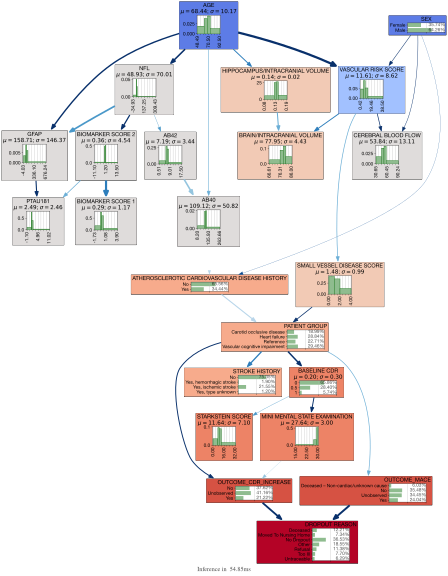

OSError: no library called "cairo-2" was found
no library called "cairo" was found
no library called "libcairo-2" was found
cannot load library 'libcairo.so.2': dlopen(libcairo.so.2, 0x0002): tried: 'libcairo.so.2' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibcairo.so.2' (no such file), '/usr/lib/libcairo.so.2' (no such file, not in dyld cache), 'libcairo.so.2' (no such file).  Additionally, ctypes.util.find_library() did not manage to locate a library called 'libcairo.so.2'
cannot load library 'libcairo.2.dylib': dlopen(libcairo.2.dylib, 0x0002): tried: 'libcairo.2.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibcairo.2.dylib' (no such file), '/usr/lib/libcairo.2.dylib' (no such file, not in dyld cache), 'libcairo.2.dylib' (no such file).  Additionally, ctypes.util.find_library() did not manage to locate a library called 'libcairo.2.dylib'
cannot load library 'libcairo-2.dll': dlopen(libcairo-2.dll, 0x0002): tried: 'libcairo-2.dll' (no such file), '/System/Vo

In [64]:
# Plot with MI-based edge widths
gnb.showInference(
    bn_with_biomarkers,
    arcWidth=arc_width,
    nodeColor=node_colors,
    arcColor=arc_color_values,
    cmapArc=plt.get_cmap("Blues"),
    cmapNode=plt.get_cmap("coolwarm")
    )

# Save as PDF (editable in Illustrator)
gumimage.exportInference(
    bn_with_biomarkers,
    str(OUTPUT_GRAPHS_DIR / 'bn_biomarkers_inference.pdf'),
    arcWidth=arc_width,
    nodeColor=node_colors,
    arcColor=arc_color_values,
    cmapArc=plt.get_cmap("Blues"),
    cmapNode=plt.get_cmap("coolwarm"),
)
print(f"Saved: {OUTPUT_GRAPHS_DIR / 'bn_biomarkers_inference.pdf'}")


In [65]:
arc_label = {
    arc: f"f={int(bootstrap_freq_id.get(arc, 0.0) * 100)}%"
    for arc in bn_with_biomarkers.arcs()
}

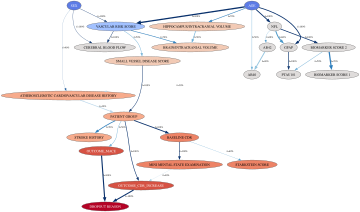

Saved: <PROJECT_ROOT>/outputs/graphs/bn_biomarkers_structure.pdf


In [66]:
# Plot with MI-based edge widths
gnb.showBN(
    bn_with_biomarkers,
    arcWidth=arc_width,
    nodeColor=node_colors,
    arcColor=arc_color_values,
    arcLabel=arc_label,
    cmapNode=plt.get_cmap("coolwarm"),
    cmapArc=plt.get_cmap("Blues")
)

# Save as PDF (editable in Illustrator)
gumimage.export(
    bn_with_biomarkers,
    str(OUTPUT_GRAPHS_DIR / 'bn_biomarkers_structure.pdf'),
    arcWidth=arc_width,
    nodeColor=node_colors,
    arcColor=arc_color_values,
    arcLabel=arc_label,
    cmapNode=plt.get_cmap("coolwarm"),
    cmapArc=plt.get_cmap("Blues"),
)
print(f"Saved: {OUTPUT_GRAPHS_DIR / 'bn_biomarkers_structure.pdf'}")


The specialised biomarkers appear upstream but are not directly connected to the outcomes; removing the layer leaves predictive behaviour largely unchanged.

In [67]:
gnb.showTensor(bn_with_biomarkers.cpt(bn_with_biomarkers.idFromName("OUTCOME_CDR_INCREASE")), digits=2)

In [68]:
gnb.showTensor(bn_with_biomarkers.cpt(bn_with_biomarkers.idFromName("OUTCOME_MACE")), digits=2)

In [69]:
# Initialize inference engine
ie = gum.LazyPropagation(bn_with_biomarkers)

# Get all variables in the network except the outcome
all_variables = bn_with_biomarkers.names()
variables_to_test = [var for var in all_variables if var != 'OUTCOME_MACE']

# Store results
mi_results = {}

for var in variables_to_test:
    try:
        it = gum.InformationTheory(ie, 'OUTCOME_MACE', [var])
        mi = it.mutualInformationXY()  # Without correction
        mi_results[var] = mi
        print(f'Mutual Information ({var} -> OUTCOME_MACE): {mi:.6f}')
    except Exception as e:
        print(f'Error processing variable {var}: {e}')

# Optional: sort results
sorted_mi = sorted(mi_results.items(), key=lambda x: x[1], reverse=True)

print("\nVariable Importance Ranking for OUTCOME_MACE (Raw Mutual Information)")
for var, score in sorted_mi:
    print(f'{var}: {score:.6f}')

Mutual Information (STROKE HISTORY -> OUTCOME_MACE): 0.002837
Mutual Information (PTAU181 -> OUTCOME_MACE): 0.000014
Mutual Information (HIPPOCAMPUS/INTRACRANIAL VOLUME -> OUTCOME_MACE): 0.000028
Mutual Information (BRAIN/INTRACRANIAL VOLUME -> OUTCOME_MACE): 0.000072
Mutual Information (BIOMARKER SCORE 1 -> OUTCOME_MACE): 0.000006
Mutual Information (AB42 -> OUTCOME_MACE): 0.000074
Mutual Information (AGE -> OUTCOME_MACE): 0.000198
Mutual Information (AB40 -> OUTCOME_MACE): 0.000321
Mutual Information (PATIENT GROUP -> OUTCOME_MACE): 0.081141
Error processing variable DROPOUT REASON: [pyAgrum] Undefined element: The variable DROPOUT REASON(20) does not belong to this optimized inference.
Mutual Information (ATHEROSCLEROTIC CARDIOVASCULAR DISEASE HISTORY -> OUTCOME_MACE): 0.008109
Mutual Information (CEREBRAL BLOOD FLOW -> OUTCOME_MACE): 0.000102
Mutual Information (MINI MENTAL STATE EXAMINATION -> OUTCOME_MACE): 0.000685
Mutual Information (GFAP -> OUTCOME_MACE): 0.000058
Mutual Infor

In [70]:
# Initialize inference engine
ie = gum.LazyPropagation(bn_with_biomarkers)

# Get all variables in the network except the outcome
all_variables = bn_with_biomarkers.names()
variables_to_test = [var for var in all_variables if var != 'OUTCOME_CDR_INCREASE']

# Store results
mi_results = {}

for var in variables_to_test:
    try:
        it = gum.InformationTheory(ie, 'OUTCOME_CDR_INCREASE', [var])
        mi = it.mutualInformationXY()  # Without correction
        mi_results[var] = mi
        print(f'Mutual Information ({var} -> OUTCOME_CDR_INCREASE): {mi:.6f}')
    except Exception as e:
        print(f'Error processing variable {var}: {e}')

# Optional: sort results
sorted_mi = sorted(mi_results.items(), key=lambda x: x[1], reverse=True)

print("\nVariable Importance Ranking for OUTCOME_CDR_INCREASE (Raw Mutual Information)")
for var, score in sorted_mi:
    print(f'{var}: {score:.6f}')

Mutual Information (STROKE HISTORY -> OUTCOME_CDR_INCREASE): 0.007294
Mutual Information (PTAU181 -> OUTCOME_CDR_INCREASE): 0.000023
Mutual Information (HIPPOCAMPUS/INTRACRANIAL VOLUME -> OUTCOME_CDR_INCREASE): 0.000052
Mutual Information (BRAIN/INTRACRANIAL VOLUME -> OUTCOME_CDR_INCREASE): 0.000127
Mutual Information (BIOMARKER SCORE 1 -> OUTCOME_CDR_INCREASE): 0.000009
Mutual Information (OUTCOME_MACE -> OUTCOME_CDR_INCREASE): 0.008893
Mutual Information (AB42 -> OUTCOME_CDR_INCREASE): 0.000071
Mutual Information (AGE -> OUTCOME_CDR_INCREASE): 0.000365
Mutual Information (AB40 -> OUTCOME_CDR_INCREASE): 0.000315
Mutual Information (PATIENT GROUP -> OUTCOME_CDR_INCREASE): 0.128834
Error processing variable DROPOUT REASON: [pyAgrum] Undefined element: The variable DROPOUT REASON(20) does not belong to this optimized inference.
Mutual Information (ATHEROSCLEROTIC CARDIOVASCULAR DISEASE HISTORY -> OUTCOME_CDR_INCREASE): 0.008593
Mutual Information (CEREBRAL BLOOD FLOW -> OUTCOME_CDR_INCRE

In [71]:
# Initialize inference engine
ie = gum.LazyPropagation(bn_with_biomarkers)

# Get the parents of OUTCOME_CDR_INCREASE
parents = bn_with_biomarkers.parents(bn_with_biomarkers.idFromName('OUTCOME_CDR_INCREASE'))
parent_names = [bn_with_biomarkers.variable(p).name() for p in parents]

# Get all variables in the network except OUTCOME_CDR_INCREASE and its parents
all_variables = bn_with_biomarkers.names()
variables_to_test = [var for var in all_variables if var != 'OUTCOME_CDR_INCREASE' and var not in parent_names]

# Initialize dictionary to store results
cmi_results = {}

# Loop through each variable and compute conditional mutual information
for var in variables_to_test:
    try:
        it = gum.InformationTheory(ie, 'OUTCOME_CDR_INCREASE', [var], parent_names)
        cmi = it.mutualInformationXYgivenZ()
        cmi_results[var] = cmi
        print(f'Corrected MI ({var} -> OUTCOME_CDR_INCREASE | {parent_names}): {cmi:.6f}')
    except Exception as e:
        print(f'Error processing variable {var}: {e}')

# Optional: sort and display ranking
sorted_cmi = sorted(cmi_results.items(), key=lambda x: x[1], reverse=True)

print("\nVariable Importance Ranking for OUTCOME_CDR_INCREASE (Corrected Mutual Information)")
for var, score in sorted_cmi:
    print(f'{var}: {score:.6f}')

Corrected MI (STROKE HISTORY -> OUTCOME_CDR_INCREASE | ['PATIENT GROUP', 'MINI MENTAL STATE EXAMINATION']): 0.000000
Corrected MI (PTAU181 -> OUTCOME_CDR_INCREASE | ['PATIENT GROUP', 'MINI MENTAL STATE EXAMINATION']): 0.000000
Corrected MI (HIPPOCAMPUS/INTRACRANIAL VOLUME -> OUTCOME_CDR_INCREASE | ['PATIENT GROUP', 'MINI MENTAL STATE EXAMINATION']): 0.000000
Corrected MI (BRAIN/INTRACRANIAL VOLUME -> OUTCOME_CDR_INCREASE | ['PATIENT GROUP', 'MINI MENTAL STATE EXAMINATION']): 0.000000
Corrected MI (BIOMARKER SCORE 1 -> OUTCOME_CDR_INCREASE | ['PATIENT GROUP', 'MINI MENTAL STATE EXAMINATION']): -0.000000
Corrected MI (OUTCOME_MACE -> OUTCOME_CDR_INCREASE | ['PATIENT GROUP', 'MINI MENTAL STATE EXAMINATION']): 0.000000
Corrected MI (AB42 -> OUTCOME_CDR_INCREASE | ['PATIENT GROUP', 'MINI MENTAL STATE EXAMINATION']): 0.000000
Corrected MI (AGE -> OUTCOME_CDR_INCREASE | ['PATIENT GROUP', 'MINI MENTAL STATE EXAMINATION']): -0.000000
Corrected MI (AB40 -> OUTCOME_CDR_INCREASE | ['PATIENT GROUP'

## 8. Scenario Exploration

Explore illustrative patient trajectories via direct inference and narrative summaries.

### 8.1 Bootstrapped outcome risks

Quantify uncertainty around the scenario-level outcome probabilities by refitting the joint network on bootstrap resamples and re-running inference for each patient profile.

In [72]:
# `bootstrap_scenario_risks` comes from `core.bn_utils` (imported in cell 2).
# The profiles, their display labels and the bootstrap count are read from
# spec.yml -> analyses.scenarios. See PORT_DIFF.md §25.

healthy_evs = SCENARIO_EVS['Healthy profile']
ill_evs = SCENARIO_EVS['Ill profile']

scenario_profiles = list(SPEC.scenarios.profiles)

target_outcomes = list(SPEC.scenarios.targets)

scenario_bootstrap_summary = bootstrap_scenario_risks(
    df=df_imp,
    scenario_profiles=scenario_profiles,
    target_outcomes=target_outcomes,
    build_bn_func=build_bn,
    layer_map=layer_map,
    type_processor=type_processor,
    outcomes_for_learning=list(SPEC.variant("joint").outcomes),
    exclude_layers=HBC_EXCLUDE_LAYERS,
    n_bootstraps=SPEC.scenarios.bootstrap_n,
    **LEARN_KWARGS
)

display(scenario_bootstrap_summary)


,Scenario,Outcome,Category,Mean probability,Std,CI 2.5%,CI 97.5%,Bootstraps
0,Healthy profile,CDR increase,No,0.607590,0.082005,0.450232,0.765479,200
1,Healthy profile,CDR increase,Unobserved,0.269461,0.054760,0.154490,0.378172,200
2,Healthy profile,CDR increase,Yes,0.122949,0.053355,0.039901,0.227804,200
3,Healthy profile,MACE event,Deceased – Non-cardiac/unknown cause,0.069756,0.039805,0.012489,0.158090,200
4,Healthy profile,MACE event,No,0.552348,0.088313,0.374507,0.724452,200
5,Healthy profile,MACE event,Unobserved,0.244598,0.049661,0.159629,0.333609,200
6,Healthy profile,MACE event,Yes,0.133299,0.045178,0.039752,0.216306,200
7,Ill profile,CDR increase,No,0.257617,0.042205,0.168878,0.339995,200
8,Ill profile,CDR increase,Unobserved,0.346487,0.058464,0.247228,0.458310,200
9,Ill profile,CDR increase,Yes,0.395896,0.058376,0.305506,0.529567,200


In [73]:
ie = gum.LazyPropagation(bn_joint)

# Healthy profile (spec.yml -> analyses.scenarios.profiles)
healthy_evs = SCENARIO_EVS['Healthy profile']

# Calculate probabilities for healthy patient
ie.setEvidence(healthy_evs)
healthy_posterior = ie.posterior('OUTCOME_CDR_INCREASE')
print("Healthy Patient - OUTCOME_CDR_INCREASE probabilities:")
healthy_posterior

Healthy Patient - OUTCOME_CDR_INCREASE probabilities:


(pyagrum.Tensor@0xb78ac17a0) 
  OUTCOME_CDR_INCREASE       |
No       |Unobserve|Yes      |
---------|---------|---------|
 0.6854  | 0.2697  | 0.0449  |

In [74]:
# Calculate probabilities for healthy patient
ie.setEvidence(healthy_evs)
healthy_posterior = ie.posterior('OUTCOME_MACE')
print("Healthy Patient - OUTCOME_MACE probabilities:")
healthy_posterior

Healthy Patient - OUTCOME_MACE probabilities:


(pyagrum.Tensor@0xb78ab25a0) 
  OUTCOME_MACE                         |
Deceased |No       |Unobserve|Yes      |
---------|---------|---------|---------|
 0.0075  | 0.6165  | 0.2406  | 0.1353  |

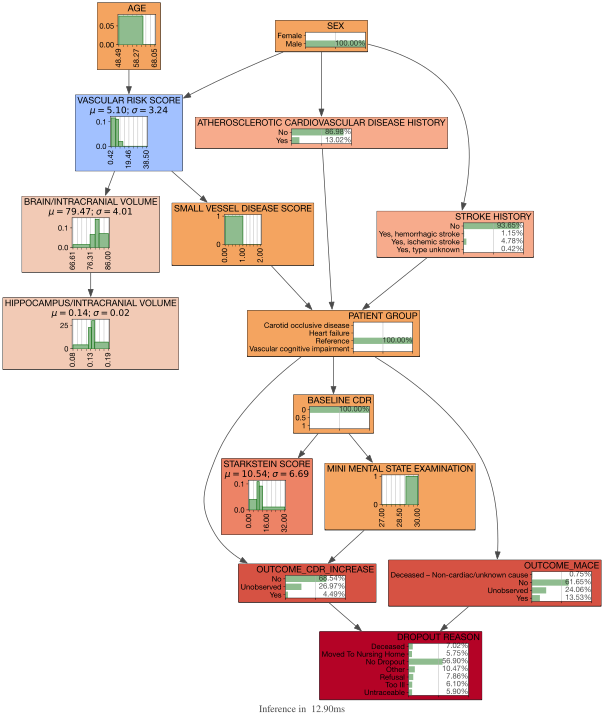

OSError: no library called "cairo-2" was found
no library called "cairo" was found
no library called "libcairo-2" was found
cannot load library 'libcairo.so.2': dlopen(libcairo.so.2, 0x0002): tried: 'libcairo.so.2' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibcairo.so.2' (no such file), '/usr/lib/libcairo.so.2' (no such file, not in dyld cache), 'libcairo.so.2' (no such file).  Additionally, ctypes.util.find_library() did not manage to locate a library called 'libcairo.so.2'
cannot load library 'libcairo.2.dylib': dlopen(libcairo.2.dylib, 0x0002): tried: 'libcairo.2.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibcairo.2.dylib' (no such file), '/usr/lib/libcairo.2.dylib' (no such file, not in dyld cache), 'libcairo.2.dylib' (no such file).  Additionally, ctypes.util.find_library() did not manage to locate a library called 'libcairo.2.dylib'
cannot load library 'libcairo-2.dll': dlopen(libcairo-2.dll, 0x0002): tried: 'libcairo-2.dll' (no such file), '/System/Vo

In [75]:
gnb.showInference(bn_joint, 
                  evs=healthy_evs, 
                  size="10!", 
                  nodeColor=node_colors, 
                  cmapNode=plt.get_cmap("coolwarm"))

# Save as PDF (editable in Illustrator)
gumimage.exportInference(
    bn_joint,
    str(OUTPUT_GRAPHS_DIR / 'bn_joint_healthy_evidence.pdf'),
    evs=healthy_evs,
    size="10!",
    nodeColor=node_colors,
    cmapNode=plt.get_cmap("coolwarm"),
)
print(f"Saved: {OUTPUT_GRAPHS_DIR / 'bn_joint_healthy_evidence.pdf'}")


In [76]:
ie = gum.LazyPropagation(bn_joint)

# Ill profile (spec.yml -> analyses.scenarios.profiles)
ill_evs = SCENARIO_EVS['Ill profile']

# Calculate probabilities for ill patient
ie.setEvidence(ill_evs)
ill_posterior = ie.posterior('OUTCOME_CDR_INCREASE')
print("Ill Patient - OUTCOME_CDR_INCREASE probabilities:")
ill_posterior

Ill Patient - OUTCOME_CDR_INCREASE probabilities:


(pyagrum.Tensor@0xb783ac5a0) 
  OUTCOME_CDR_INCREASE       |
No       |Unobserve|Yes      |
---------|---------|---------|
 0.2770  | 0.3547  | 0.3683  |

In [77]:
# Calculate probabilities for ill patient
ie.setEvidence(ill_evs)
ill_posterior = ie.posterior('OUTCOME_MACE')
print("Ill Patient - OUTCOME_MACE probabilities:")
ill_posterior

Ill Patient - OUTCOME_MACE probabilities:


(pyagrum.Tensor@0xb783ad1e0) 
  OUTCOME_MACE                         |
Deceased |No       |Unobserve|Yes      |
---------|---------|---------|---------|
 0.0706  | 0.2882  | 0.3882  | 0.2529  |

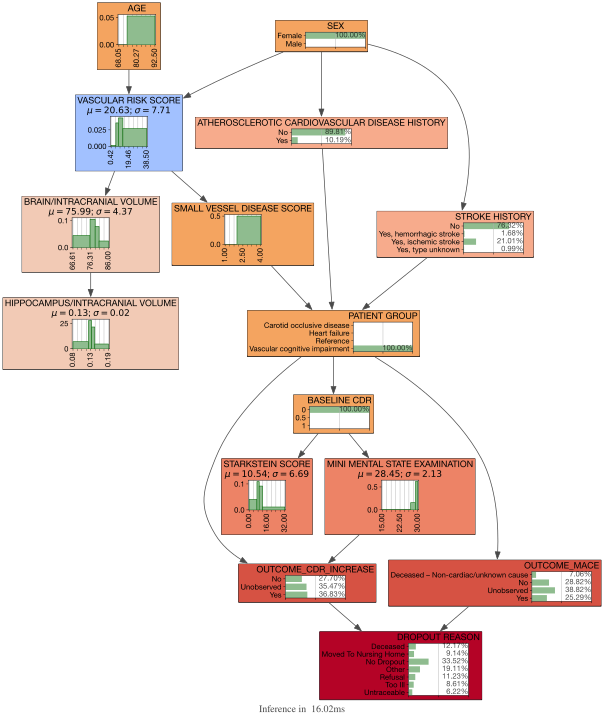

OSError: no library called "cairo-2" was found
no library called "cairo" was found
no library called "libcairo-2" was found
cannot load library 'libcairo.so.2': dlopen(libcairo.so.2, 0x0002): tried: 'libcairo.so.2' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibcairo.so.2' (no such file), '/usr/lib/libcairo.so.2' (no such file, not in dyld cache), 'libcairo.so.2' (no such file).  Additionally, ctypes.util.find_library() did not manage to locate a library called 'libcairo.so.2'
cannot load library 'libcairo.2.dylib': dlopen(libcairo.2.dylib, 0x0002): tried: 'libcairo.2.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibcairo.2.dylib' (no such file), '/usr/lib/libcairo.2.dylib' (no such file, not in dyld cache), 'libcairo.2.dylib' (no such file).  Additionally, ctypes.util.find_library() did not manage to locate a library called 'libcairo.2.dylib'
cannot load library 'libcairo-2.dll': dlopen(libcairo-2.dll, 0x0002): tried: 'libcairo-2.dll' (no such file), '/System/Vo

In [78]:
gnb.showInference(bn_joint, evs=ill_evs, size="10!", nodeColor=node_colors, cmapNode=plt.get_cmap("coolwarm"))

# Save as PDF (editable in Illustrator)
gumimage.exportInference(
    bn_joint,
    str(OUTPUT_GRAPHS_DIR / 'bn_joint_ill_evidence.pdf'),
    evs=ill_evs,
    size="10!",
    nodeColor=node_colors,
    cmapNode=plt.get_cmap("coolwarm"),
)
print(f"Saved: {OUTPUT_GRAPHS_DIR / 'bn_joint_ill_evidence.pdf'}")


### 8.2 How the outcomes respond to small vessel disease burden

Section 8.1 gives one risk estimate per fixed patient. Here we instead
**turn a single knob** — the SVD score — for an otherwise fixed patient,
and watch how the outcome probabilities move as that one variable changes.

For a fixed patient profile we set the SVD score to each of its states in
turn and read, from the learned network,

`P(outcome = state | fixed patient, SVD score = s)`

for every outcome state. Repeating this over 200 bootstrap resamples
(patients resampled, structure and parameters re-learned, discretisation
bins fixed, Laplace-smoothed parameters) gives a 95% interval for each
point.

**How to read the figure.** One panel per outcome; the x-axis is the SVD
score; each line is one outcome state with a shaded 95% bootstrap
interval. A line that rises or falls across the x-axis shows that the
outcome probability is sensitive to SVD burden; the width of the band
shows how certain that estimate is.

**What to hold fixed — and what not to.** The SVD score influences the
outcomes only *through* downstream variables (patient group, baseline CDR).
If the fixed patient holds one of those mediators constant, the knob's
pathway is blocked and the lines look flat — not because SVD burden is
irrelevant, but because its effect has been conditioned away. The fixed
patient should therefore hold constant only variables *upstream* of the
knob (age, sex); mediators are left unobserved so the knob's full influence
can propagate. The cell prints a warning if a mediator is fixed.

**Statistically.** Each value is a conditional probability under the joint
distribution the network encodes — it is *associational* (it describes
patients who differ in SVD score), not the causal effect of changing a
patient's SVD score.


In [291]:
# ── 8.2 · Single-knob sensitivity analysis ───────────────────────────────
# Fix a patient, vary ONE variable across all its states, and read how the
# outcome probabilities respond — each with a bootstrap 95% interval.
#
# `bootstrap_knob_sweep`, `_state_for_value`, `_descendants` and
# `plot_knob_sweep` now come from `core.bn_utils` / `core.discretisation` /
# `core.plotting` (imported in cell 2); `_reduced_frame` is reproduced by
# core's internal `_reduced_for_template` once `exclude_layers` is forwarded.
# The local copies were identical apart from the hardcoded excluded layer and
# learning outcomes, which the call below now passes explicitly.
# See PORT_DIFF.md §26-30.

# Outcomes the network is always *learned* with (kept fixed for comparability).
_LEARN_OUTCOMES = list(SPEC.variant("joint").outcomes)


<HOME>/Library/Python/3.13/lib/python/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
<HOME>/Library/Python/3.13/lib/python/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
<HOME>/Library/Python/3.13/lib/python/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_

[aGrUM notification] The K2 score already contains a different 'implicit' prior. Therefore, the learning will probably be biased.
Fixed patient — evidence applied : {'PATIENT GROUP': 'Vascular cognitive impairment', 'SEX': 'Female', 'AGE': '[68.0452;73.6283['}
Fixed patient — numeric values snapped to bin: {'AGE': "72 -> '[68.0452;73.6283['"}
[aGrUM notification] The K2 score already contains a different 'implicit' prior. Therefore, the learning will probably be biased.
[aGrUM notification] The K2 score already contains a different 'implicit' prior. Therefore, the learning will probably be biased.
[aGrUM notification] The K2 score already contains a different 'implicit' prior. Therefore, the learning will probably be biased.
[aGrUM notification] The K2 score already contains a different 'implicit' prior. Therefore, the learning will probably be biased.
[aGrUM notification] The K2 score already contains a different 'implicit' prior. Therefore, the learning will probably be biased.
[aGrU

,Outcome,SMALL VESSEL DISEASE SCORE,Outcome state,P,CI_low,CI_high,Bootstraps
0,OUTCOME_CDR_INCREASE,(0;1[,No,0.292,0.209,0.355,200
1,OUTCOME_CDR_INCREASE,(0;1[,Unobserved,0.351,0.289,0.432,200
2,OUTCOME_CDR_INCREASE,(0;1[,Yes,0.357,0.290,0.435,200
3,OUTCOME_MACE,(0;1[,No,0.566,0.318,1.000,200
4,OUTCOME_MACE,(0;1[,Unobserved,0.225,0.000,0.383,200
5,OUTCOME_MACE,(0;1[,Yes,0.208,0.000,0.345,200
6,OUTCOME_CDR_INCREASE,[1;2[,No,0.280,0.193,0.348,200
7,OUTCOME_CDR_INCREASE,[1;2[,Unobserved,0.351,0.285,0.432,200
8,OUTCOME_CDR_INCREASE,[1;2[,Yes,0.368,0.302,0.453,200
9,OUTCOME_MACE,[1;2[,No,0.558,0.294,1.000,200


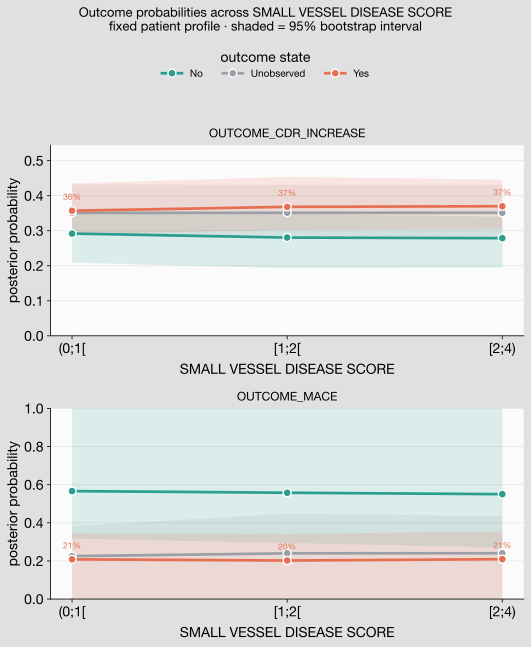

In [292]:
# ── Configure the sensitivity analysis ───────────────────────────────────
# All four settings come from spec.yml -> analyses.knob_sweep.
#
# 1) Fixed patient: held constant while the knob is varied.
#    IMPORTANT — only hold constant variables UPSTREAM of the knob (age,
#    sex). Fixing a downstream variable (PATIENT GROUP, BASELINE CDR) would
#    block the pathway through which the knob acts on the outcomes and make
#    the knob look inert; the cell prints a warning if you do.
#    Numeric values (e.g. AGE) are snapped to the bin that contains them.
base_profile = dict(SPEC.knob_sweep.base_profile)

# 2) The single variable we vary across all of its states.
knob = SPEC.knob_sweep.knob

# 3) Outcomes to show — every state of each outcome is plotted.
outcomes = list(SPEC.knob_sweep.outcomes)

sweep_df, sweep_meta = bootstrap_knob_sweep(
    df=df_imp,
    base_profile=base_profile,
    knob=knob,
    outcomes=outcomes,
    outcomes_for_learning=_LEARN_OUTCOMES,
    build_bn_func=build_bn,
    layer_map=layer_map,
    type_processor=type_processor,
    exclude_layers=HBC_EXCLUDE_LAYERS,
    n_bootstraps=SPEC.knob_sweep.bootstrap_n,
    **LEARN_KWARGS
)

display(sweep_df.round(3))
plot_knob_sweep(sweep_df, sweep_meta)


## 9. Persistence and Next Steps

Export the trained network and outline follow-up visual summaries.

In [ ]:
# Persist the joint network for reuse outside the notebook
gum.saveBN(bn_joint, "bn_joint.bifxml")  # You can also use .net or .xdsl
